<a href="https://colab.research.google.com/github/donna6355/study_python/blob/master/disability/voc_clustering_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 시각장애 보조기기 VOC 클러스터링 분석
### 파이프라인 순서
1. 데이터 로드 & 전처리
2. 임베딩 (paraphrase-multilingual-mpnet-base-v2)
3. PCA 차원 축소
4. 최적 K 탐색 (Elbow + Silhouette + Davies-Bouldin)
5. 후보 K 복수 적용 + 덴드로그램
6. 클러스터별 TF-IDF 키워드 해석
7. 클러스터별 LDA 세부 토픽 분리

> **저장 파일 목록**
> - `01_df_cleaned.pkl` : 전처리 완료 데이터프레임
> - `02_embeddings.npy` : 임베딩 벡터 (numpy)
> - `03_df_with_embeddings.pkl` : 임베딩 컬럼 포함 데이터프레임
> - `04_pca_result.npy` : PCA 축소 결과
> - `05_df_with_clusters.pkl` : 클러스터 컬럼 포함 최종 데이터프레임

---
## STEP 0. 라이브러리 설치

In [ ]:
# 최초 1회만 실행
# 맥북 M5 로컬 환경 기준
!pip install sentence-transformers scikit-learn scipy tqdm matplotlib pandas numpy

---
## STEP 1. 데이터 로드 & 전처리

In [ ]:
import pandas as pd
import numpy as np
import os

# ── 로드 ──────────────────────────────────────────────────
df = pd.read_csv('./data.csv')
print(f"원본 shape: {df.shape}")
print(f"\n컬럼: {df.columns.tolist()}")
# print(f"\nlang 분포:\n{df['lang'].value_counts()}")
# print(f"\nsource 분포:\n{df['source'].value_counts()}")

In [ ]:
# ── 전처리 ────────────────────────────────────────────────

# 1. text 결측치 제거 (text_ko는 이미 결측 없음 확인됨)
df = df.dropna(subset=['text'])

# 2. 인덱스 리셋 — 임베딩 벡터 인덱스와 1:1 매칭을 위해 필수
df = df.reset_index(drop=True)

print(f"\n최종 전처리 shape: {df.shape}")
print(f"text null: {df['text'].isna().sum()}")
# print(f"text_ko null: {df['text_ko'].isna().sum()}")

# ── 저장 01 ───────────────────────────────────────────────
df.to_pickle('01_df_cleaned.pkl')
print("\n✅ 01_df_cleaned.pkl 저장 완료")


최종 전처리 shape: (31024, 1)
text null: 0

✅ 01_df_cleaned.pkl 저장 완료


---
## STEP 2. 임베딩

- 모델: `paraphrase-multilingual-mpnet-base-v2`
- 입력: 원문 `text` 컬럼 (다국어 그대로)
- 출력: 768차원 벡터
- 디바이스: MPS (맥북 M5 GPU 가속)

> 약 15~20분 소요 예상 (M5 기준)

In [ ]:
# 셀 7 대체 코드
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [ ]:
# 셀에서 실행
import sys
print(sys.executable)
print(sys.version)

/usr/bin/python3
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
import torch
from sentence_transformers import SentenceTransformer

# 저장된 pkl 불러오기 (STEP 1 완료 후 재실행 시)
df = pd.read_pickle('01_df_cleaned.pkl')

docs = df['text'].tolist()
print(f"임베딩 대상 문서 수: {len(docs)}건")

# ── 디바이스 설정 ──────────────────────────────────────────
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"사용 디바이스: {device}")

# ── 모델 로드 ──────────────────────────────────────────────
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2', device=device)
print("모델 로드 완료")

임베딩 대상 문서 수: 31024건
사용 디바이스: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.12k [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

모델 로드 완료


In [ ]:
# ── 임베딩 실행 ────────────────────────────────────────────
embeddings = model.encode(
    docs, # 임베딩 텍스트 리스트
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True  # 벡터 길이 모두 1로 통일, 코사인 유사도 계산에 유리
)

print(f"\n임베딩 shape: {embeddings.shape}")  # (37926, 768) 예상

# ── 저장 02: npy (임베딩 벡터만 빠르게 재사용할 때) ────────
np.save('02_embeddings.npy', embeddings)
print("✅ 02_embeddings.npy 저장 완료")

# ── 저장 03: pkl (df에 임베딩 컬럼 추가해서 함께 보존) ─────
# 이전 프로젝트에서 df['embedding'] 컬럼으로 쓰던 방식
df['embedding'] = list(embeddings)
df.to_pickle('03_df_with_embeddings.pkl')
print("✅ 03_df_with_embeddings.pkl 저장 완료")

# ── 검증 ───────────────────────────────────────────────────
print(f"\n행 0 임베딩 shape: {df['embedding'].iloc[0].shape}")
print(f"df 행 수 == 임베딩 행 수: {len(df) == len(embeddings)}")

Batches:   0%|          | 0/485 [00:00<?, ?it/s]


임베딩 shape: (31024, 768)
✅ 02_embeddings.npy 저장 완료
✅ 03_df_with_embeddings.pkl 저장 완료

행 0 임베딩 shape: (768,)
df 행 수 == 임베딩 행 수: True


---
## STEP 3. PCA 차원 축소

- 768차원 → 128차원으로 축소
- KMeans는 고차원에서 거리 계산이 부정확해지는 문제(차원의 저주)가 있어서 PCA로 먼저 줄여줌
- 이전 프로젝트와 동일한 방식

In [ ]:
from sklearn.decomposition import PCA

# 재실행 시 여기서 시작
df = pd.read_pickle('03_df_with_embeddings.pkl')
# embeddings = np.load('02_embeddings.npy')

# numpy matrix로 변환 (이전 프로젝트 방식)
matrix = np.vstack(df['embedding'].values)
print(f"matrix shape: {matrix.shape}")

# ── PCA ────────────────────────────────────────────────────
pca = PCA(n_components=128, random_state=42)
result_128 = pca.fit_transform(matrix)

# 분산 설명력 확인
explained = pca.explained_variance_ratio_.sum()
print(f"PCA 완료: {matrix.shape[1]}차원 → {result_128.shape[1]}차원")
print(f"분산 설명력: {explained:.1%}")  # 80% 이상이면 충분

# ── 저장 04 ───────────────────────────────────────────────
np.save('04_pca_result.npy', result_128)
print("✅ 04_pca_result.npy 저장 완료")

matrix shape: (31024, 768)
PCA 완료: 768차원 → 128차원
분산 설명력: 90.5%
✅ 04_pca_result.npy 저장 완료


In [ ]:
# ── PCA ────────────────────────────────────────────────────
pca = PCA(n_components=0.9, random_state=42) # 설명력 90% 이상으로 자동 조정
pca_result = pca.fit_transform(matrix)

# 분산 설명력 확인
explained = pca.explained_variance_ratio_.sum()
print(f"PCA 완료: {matrix.shape[1]}차원 → {pca_result.shape[1]}차원")
print(f"분산 설명력: {explained:.1%}")  # 80% 이상이면 충분

np.save('04_pca_141.npy', pca_result)

PCA 완료: 768차원 → 124차원
분산 설명력: 90.0%


---
## STEP 4. 최적 K 탐색

세 가지 지표를 동시에 비교
- **Inertia (Elbow)**: 꺾이는 지점
- **Silhouette Score**: 높을수록 좋음
- **Davies-Bouldin Index**: 낮을수록 좋음

세 지표가 동시에 좋은 K를 후보로 선정

> 이번 데이터는 source가 7종, 다국어, pain/needs 등 다양해서 k 범위를 2~25로 넓게 잡음

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


# ── 두 차원 모두 K 탐색 ───────────────────────────────────
k_range = range(2, 26)
pca_versions = [('128차원', result_128), ('141차원', pca_result)]
all_results = {}

for pca_name, pca_result in pca_versions:
    print(f"\n{pca_name} 탐색 중...")
    inertias, silhouette_avgs, db_scores = [], [], []

    for k in tqdm(k_range, desc=pca_name):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(pca_result)
        inertias.append(kmeans.inertia_)
        silhouette_avgs.append(silhouette_score(pca_result, labels))
        db_scores.append(davies_bouldin_score(pca_result, labels))

    all_results[pca_name] = {
        'inertia': inertias,
        'silhouette': silhouette_avgs,
        'db': db_scores
    }

print("\n탐색 완료")


128차원 탐색 중...


128차원:   0%|          | 0/24 [00:00<?, ?it/s]


141차원 탐색 중...


141차원:   0%|          | 0/24 [00:00<?, ?it/s]


탐색 완료


/tmp/ipykernel_1086/1268757930.py:38: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1086/1268757930.py:38: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1086/1268757930.py:39: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_comparison.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_1086/1268757930.py:39: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.savefig('pca_comparison.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from

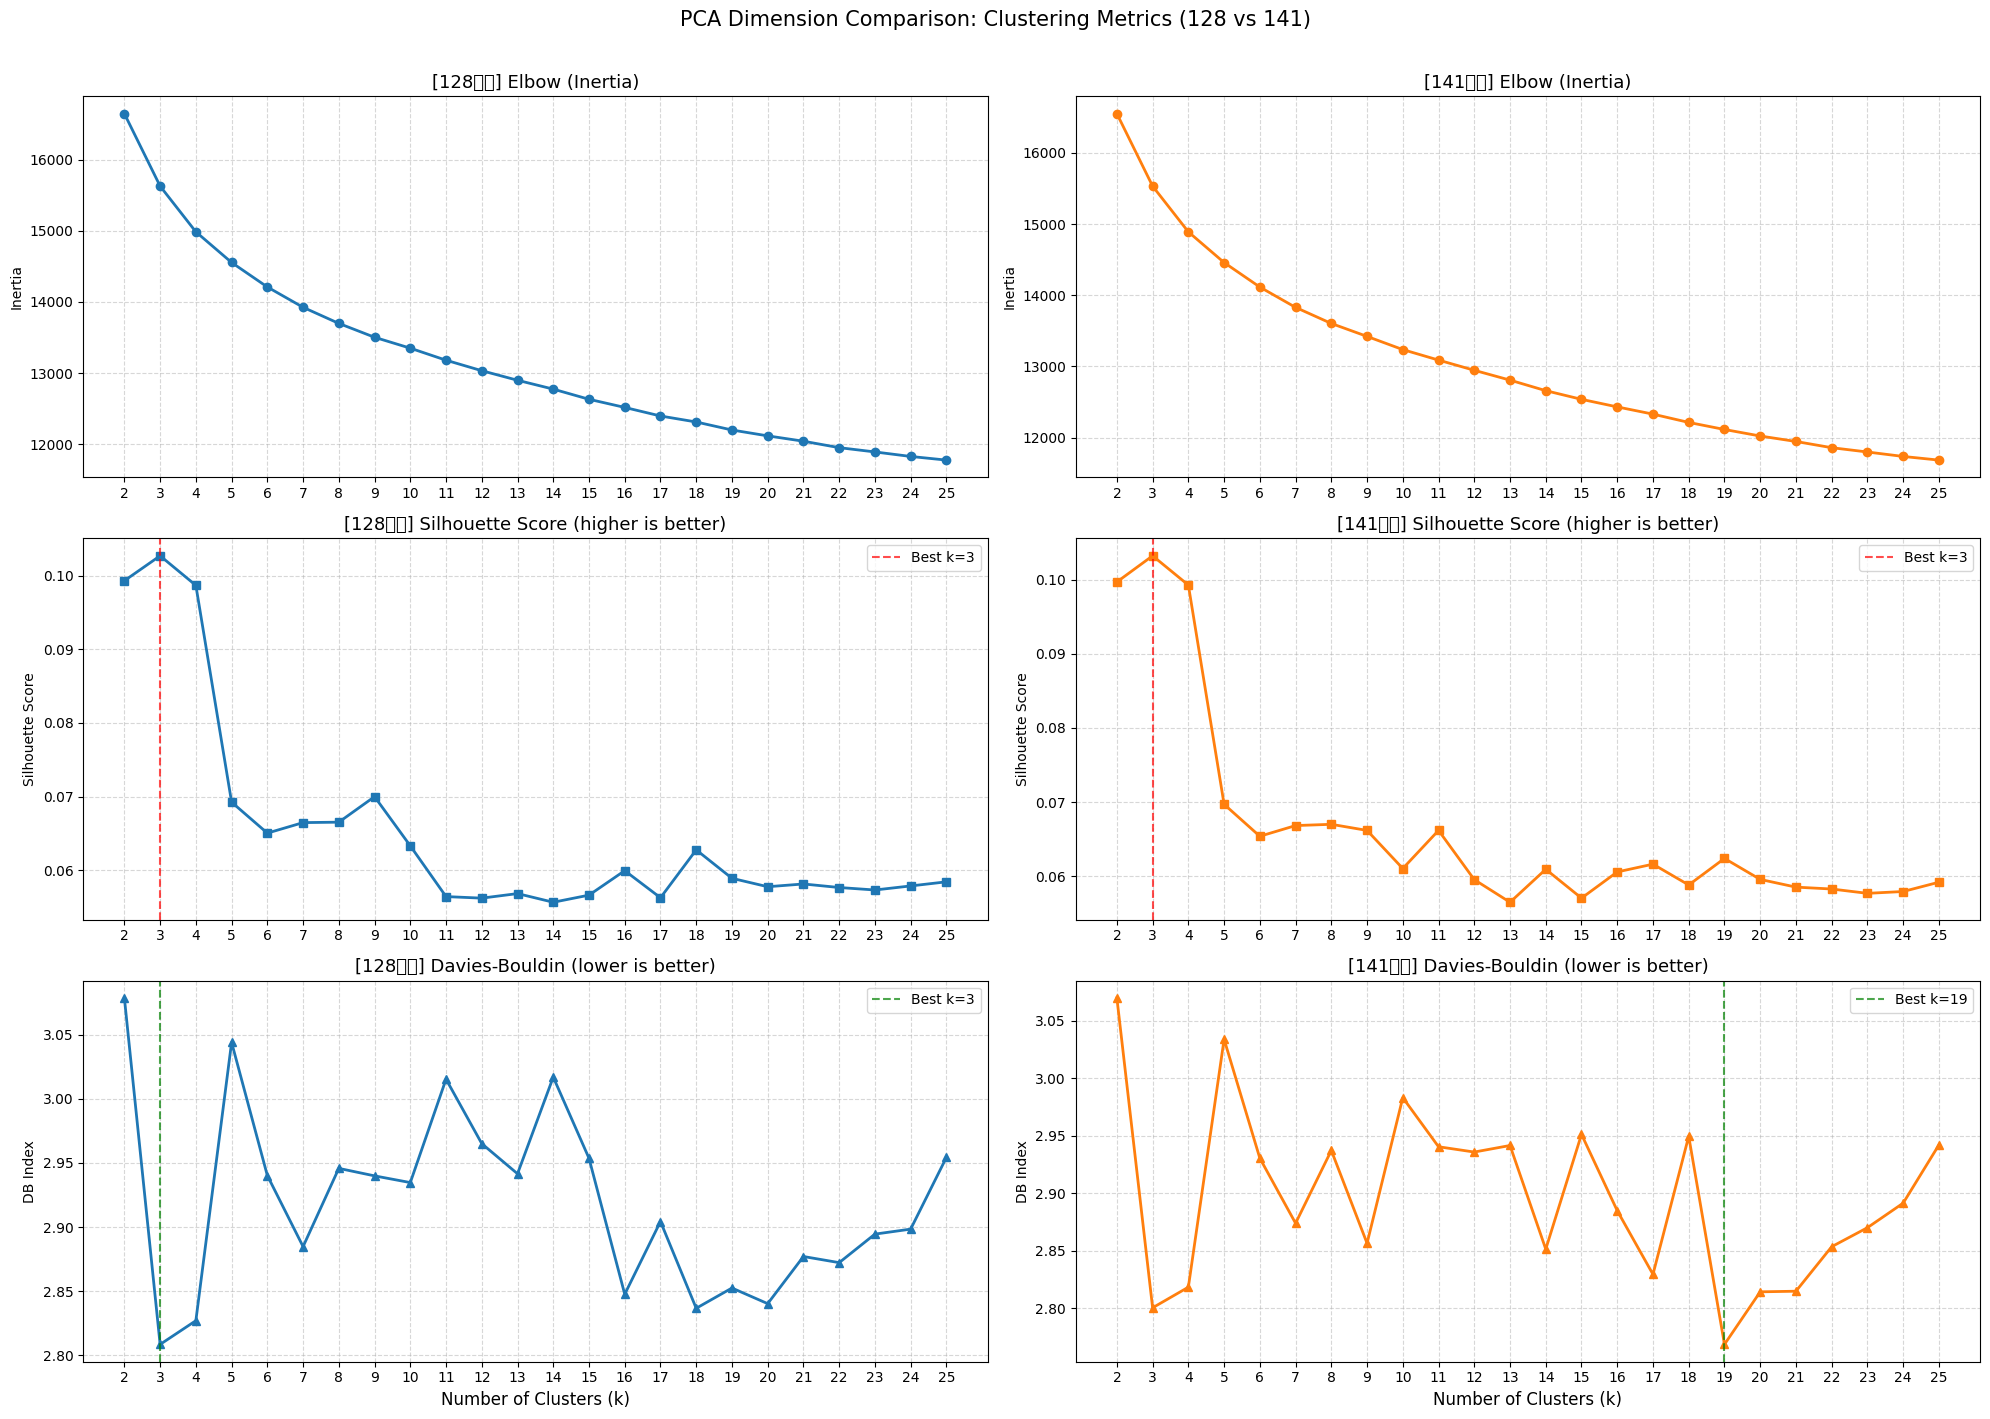


Clustering Metrics Summary
              Best Silhouette k       Best DB k
128차원      k=3 (0.1027)      k=3 (2.8085)
141차원      k=3 (0.1032)      k=19 (2.7685)


In [ ]:
# ── 시각화 ─────────────────────────────────────────────────
xticks = list(k_range)
fig, axes = plt.subplots(3, 2, figsize=(20, 14))
colors = {'128차원': 'tab:blue', '141차원': 'tab:orange'}

for col, (pca_name, res) in enumerate(all_results.items()):
    best_sil_k = k_range.start + res['silhouette'].index(max(res['silhouette']))
    best_db_k  = k_range.start + res['db'].index(min(res['db']))
    c = colors[pca_name]

    # Elbow
    axes[0][col].plot(k_range, res['inertia'], 'o-', color=c, linewidth=2, markersize=6)
    axes[0][col].set_title(f'[{pca_name}] Elbow (Inertia)', fontsize=13)
    axes[0][col].set_ylabel('Inertia')
    axes[0][col].set_xticks(xticks)
    axes[0][col].grid(True, linestyle='--', alpha=0.5)

    # Silhouette
    axes[1][col].plot(k_range, res['silhouette'], 's-', color=c, linewidth=2, markersize=6)
    axes[1][col].axvline(x=best_sil_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_sil_k}')
    axes[1][col].set_title(f'[{pca_name}] Silhouette Score (higher is better)', fontsize=13)
    axes[1][col].set_ylabel('Silhouette Score')
    axes[1][col].set_xticks(xticks)
    axes[1][col].legend()
    axes[1][col].grid(True, linestyle='--', alpha=0.5)

    # Davies-Bouldin
    axes[2][col].plot(k_range, res['db'], '^-', color=c, linewidth=2, markersize=6)
    axes[2][col].axvline(x=best_db_k, color='green', linestyle='--', alpha=0.7, label=f'Best k={best_db_k}')
    axes[2][col].set_title(f'[{pca_name}] Davies-Bouldin (lower is better)', fontsize=13)
    axes[2][col].set_xlabel('Number of Clusters (k)', fontsize=12)
    axes[2][col].set_ylabel('DB Index')
    axes[2][col].set_xticks(xticks)
    axes[2][col].legend()
    axes[2][col].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('PCA Dimension Comparison: Clustering Metrics (128 vs 141)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('pca_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 요약 출력 ─────────────────────────────────────────────
print("\nClustering Metrics Summary")
print(f"{'':10} {'Best Silhouette k':>20} {'Best DB k':>15}")
for pca_name, res in all_results.items():
    best_sil_k = k_range.start + res['silhouette'].index(max(res['silhouette']))
    best_db_k  = k_range.start + res['db'].index(min(res['db']))
    print(f"{pca_name:10} k={best_sil_k} ({max(res['silhouette']):.4f}){' ':>5} k={best_db_k} ({min(res['db']):.4f})")

### Elbow (Inertia) — 꺾이는 지점
K 늘릴수록 inertia는 무조건 내려감
→ 더 줄여도 별로 안 줄어드는 "꺾임점" = 최적
→ 한계 효용 체감 지점 찾는 거야

### Silhouette — 고점
클러스터 내부 응집도 vs 외부 분리도 비율
→ 높을수록 좋으니까 고점이 최적
→ 단, k=2 고점은 무시 (언어/극단 분리일 가능성)

### Davies-Bouldin — 저점
클러스터간 유사도 측정
→ 낮을수록 좋으니까 저점이 최적
→ 들쭉날쭉하면 전체 추세로 판단

### 128차원만 확인하는 코드

In [ ]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# 재실행 시 여기서 시작
# pca_result = np.load('04_pca_result.npy')

k_range = range(2, 21)
inertias = []
silhouette_avgs = []
db_scores = []

print("최적 K 탐색 중...")
for k in tqdm(k_range):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_result)

    inertias.append(kmeans.inertia_)
    silhouette_avgs.append(silhouette_score(pca_result, labels))
    db_scores.append(davies_bouldin_score(pca_result, labels))

print("탐색 완료")

최적 K 탐색 중...


  0%|          | 0/19 [00:00<?, ?it/s]

탐색 완료


/tmp/ipykernel_1086/315248810.py:33: UserWarning: Glyph 44734 (\N{HANGUL SYLLABLE GGEOGG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1086/315248810.py:33: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1086/315248810.py:33: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1086/315248810.py:33: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1086/315248810.py:33: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1086/315248810.py:33: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1086/315248810.py:33: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()

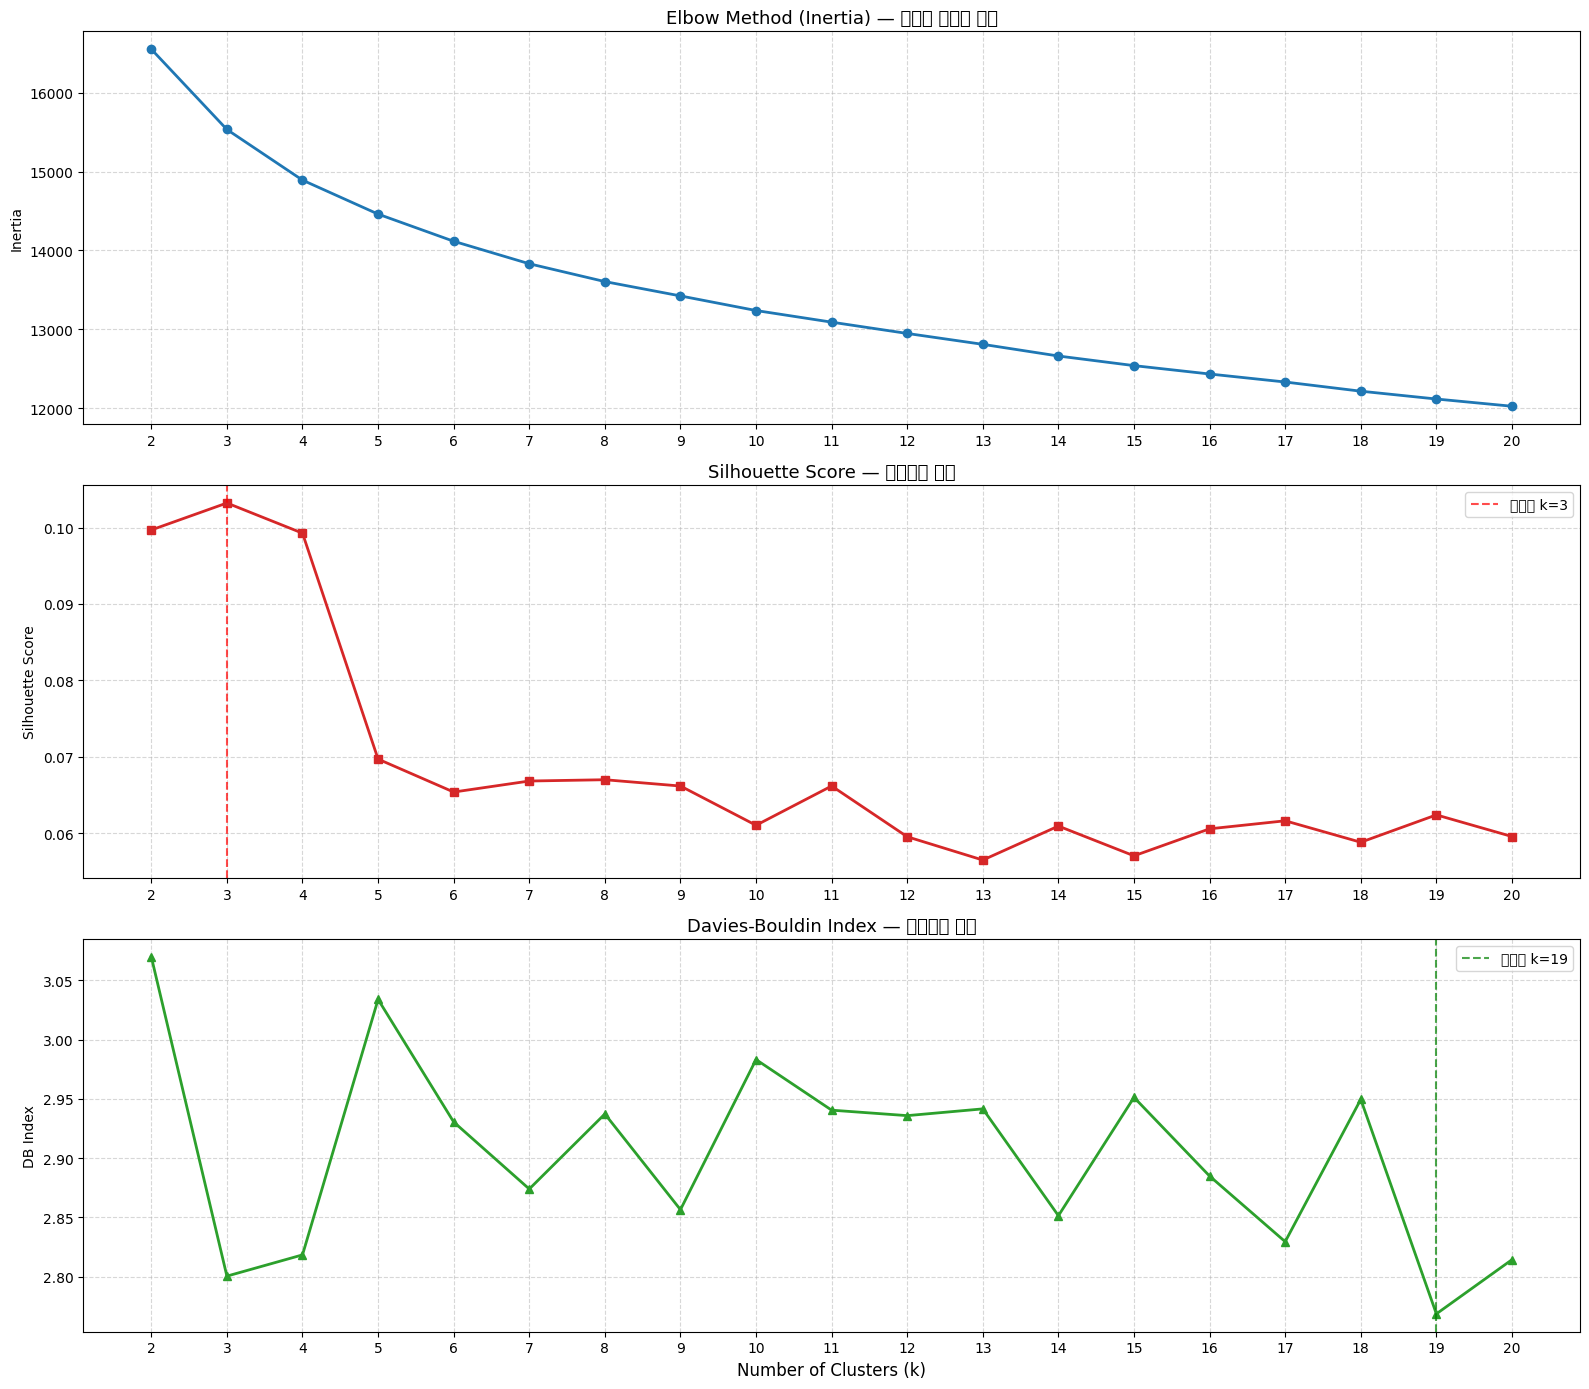


Silhouette 최고 k: 3 (score: 0.1032)
Davies-Bouldin 최저 k: 19 (score: 2.7685)

→ 그래프 보고 후보 k를 STEP 5에서 직접 지정하세요


In [ ]:
# ── 시각화 ─────────────────────────────────────────────────
xticks = list(k_range)
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Elbow
axes[0].plot(k_range, inertias, 'o-', color='tab:blue', linewidth=2, markersize=6)
axes[0].set_title('Elbow Method (Inertia) — 꺾이는 지점이 후보', fontsize=13)
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(xticks)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Silhouette
best_sil_k = k_range.start + silhouette_avgs.index(max(silhouette_avgs))
axes[1].plot(k_range, silhouette_avgs, 's-', color='tab:red', linewidth=2, markersize=6)
axes[1].axvline(x=best_sil_k, color='red', linestyle='--', alpha=0.7, label=f'최고점 k={best_sil_k}')
axes[1].set_title('Silhouette Score — 높을수록 좋음', fontsize=13)
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(xticks)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# Davies-Bouldin
best_db_k = k_range.start + db_scores.index(min(db_scores))
axes[2].plot(k_range, db_scores, '^-', color='tab:green', linewidth=2, markersize=6)
axes[2].axvline(x=best_db_k, color='green', linestyle='--', alpha=0.7, label=f'최저점 k={best_db_k}')
axes[2].set_title('Davies-Bouldin Index — 낮을수록 좋음', fontsize=13)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[2].set_ylabel('DB Index')
axes[2].set_xticks(xticks)
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('kmeans_evaluation.png', dpi=150)
plt.show()

print(f"\nSilhouette 최고 k: {best_sil_k} (score: {max(silhouette_avgs):.4f})")
print(f"Davies-Bouldin 최저 k: {best_db_k} (score: {min(db_scores):.4f})")
print("\n→ 그래프 보고 후보 k를 STEP 5에서 직접 지정하세요")

---
## STEP 5. 후보 K 복수 적용 + 덴드로그램

위 그래프를 보고 `target_ks` 리스트를 직접 수정해서 실행

  0%|          | 0/4 [00:00<?, ?it/s]


K=4 클러스터링 시작
클러스터별 데이터 수:
cluster_K4
0     4581
1     6021
2    13192
3     7230
Name: count, dtype: int64


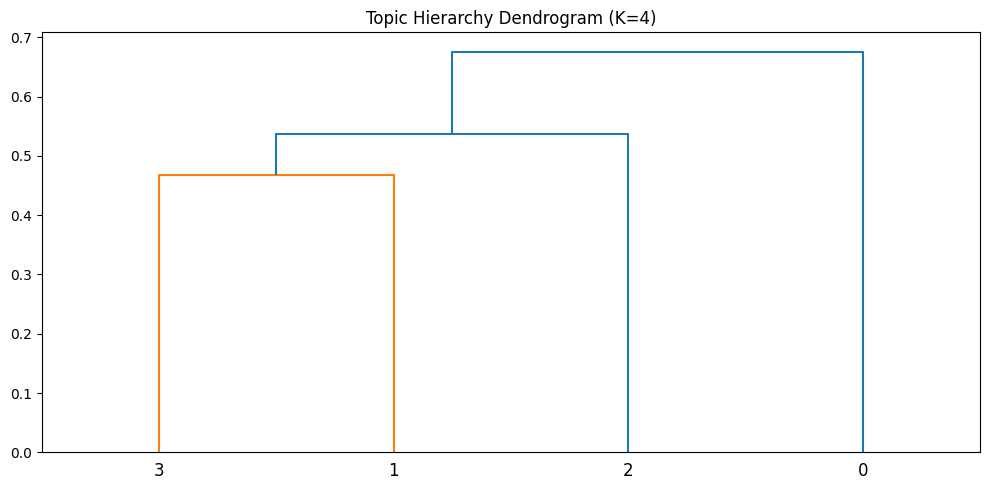


K=7 클러스터링 시작
클러스터별 데이터 수:
cluster_K7
0    5029
1    3657
2    3815
3    5800
4    2157
5    5893
6    4673
Name: count, dtype: int64


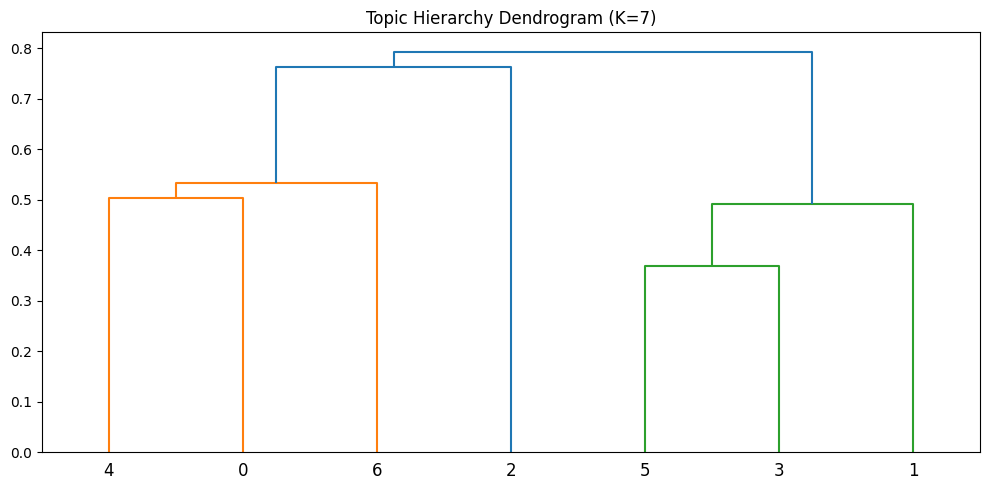


K=9 클러스터링 시작
클러스터별 데이터 수:
cluster_K9
0    3673
1    5122
2    2102
3    1855
4    5200
5    1994
6    3054
7    4520
8    3504
Name: count, dtype: int64


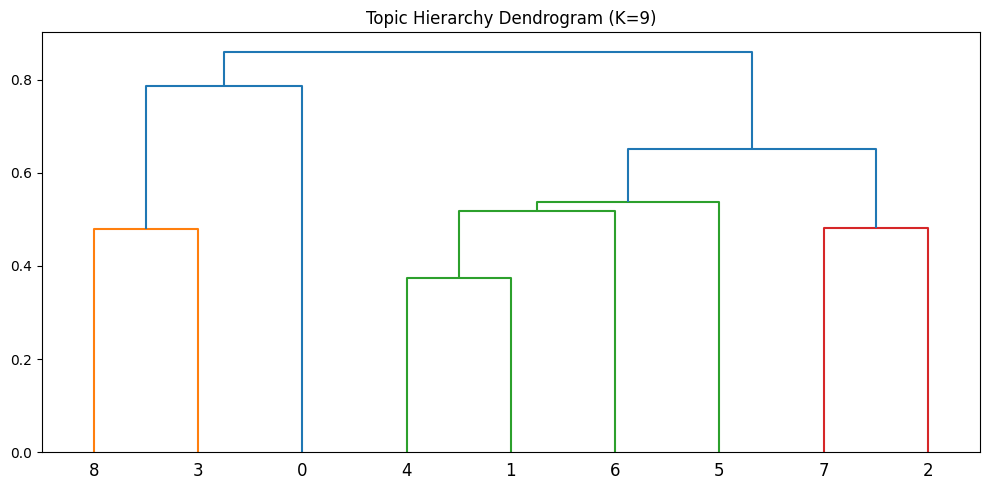


K=11 클러스터링 시작
클러스터별 데이터 수:
cluster_K11
0     2050
1     3334
2     2872
3     4256
4     2165
5     3809
6     2782
7     5054
8     2870
9     1594
10     238
Name: count, dtype: int64


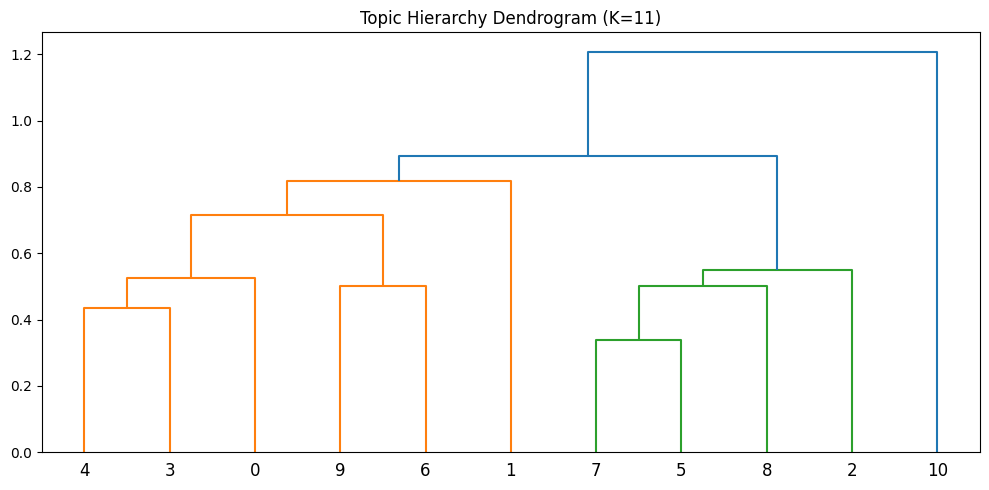


✅ 05_df_with_clusters.pkl 저장 완료

현재 컬럼: ['text', 'embedding', 'cluster_K4', 'cluster_K7', 'cluster_K9', 'cluster_K11']


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# ↓ 그래프 보고 수정
target_ks = [4, 7, 9, 11]  # 후보 k 목록

for k in tqdm(target_ks):
    print(f"\n{'='*50}")
    print(f"K={k} 클러스터링 시작")

    # KMeans 적용
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    df[f'cluster_K{k}'] = kmeans.fit_predict(pca_result)

    # 클러스터별 데이터 수 확인
    print(f"클러스터별 데이터 수:")
    print(df[f'cluster_K{k}'].value_counts().sort_index())

    # 덴드로그램 — 클러스터 중심점 간 계층 구조
    centroids = kmeans.cluster_centers_
    linked = linkage(centroids, 'ward')

    plt.figure(figsize=(10, 5))
    dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
    plt.title(f'Topic Hierarchy Dendrogram (K={k})')
    plt.tight_layout()
    plt.savefig(f'dendrogram_K{k}.png', dpi=150)
    plt.show()

# ── 저장 05 ───────────────────────────────────────────────
df.to_pickle('05_df_with_clusters.pkl')
print("\n✅ 05_df_with_clusters.pkl 저장 완료")
print(f"\n현재 컬럼: {df.columns.tolist()}")

In [ ]:
print(df.columns)

Index(['text', 'embedding', 'cluster_K4', 'cluster_K7', 'cluster_K9',
       'cluster_K11'],
      dtype='object')


In [ ]:
pd.set_option('display.max_colwidth', None)

target_ks = [4, 7, 9, 11]

for CHECK_K in target_ks:
    print(f"\n{'='*60}")
    print(f"K={CHECK_K} 전체 클러스터 샘플")
    print(f"{'='*60}")

    for CHECK_CLUSTER in sorted(df[f'cluster_K{CHECK_K}'].unique()):
        cluster_df = df[df[f'cluster_K{CHECK_K}'] == CHECK_CLUSTER]
        samples = cluster_df['text'].dropna().head(10).tolist()

        print(f"\n{'─'*60}")
        print(f"클러스터 {CHECK_CLUSTER} | 총 {len(cluster_df)}개")
        print('─'*60)
        for i, doc in enumerate(samples):
            print(f"\n[{i+1}] {doc[:300]}")

for CHECK_K in target_ks:
    print(f"\n{'='*60}")
    print(f"K={CHECK_K} Source 분포")
    print(f"{'='*60}")
    # print(df.groupby(f'cluster_K{CHECK_K}')['source'].value_counts().unstack(fill_value=0))


K=4 전체 클러스터 샘플

────────────────────────────────────────────────────────────
클러스터 0 | 총 4581개
────────────────────────────────────────────────────────────

[1] 요즘같은 겨울에는 특히 이맘때는 타이어, 튜브, 배터리 교체문의가 많을 시기입니다.
눈과 빙판길을 조심하기 위해서이죠.
앞 타이어, 튜브를 교체해줍니다.
그 후 배터리를 교체하였습니다. 워낙 자주타시는분이라 배터리는 3년만에 교체한것 같네요

[2] 썬라이즈의 박스형 헬륨휠체어 입니다.
헬륨모델은 원프레임의 간결한 디자입니다.
이런 디자인을 선호하시는 분들은 눈여겨 보셔도 될듯 싶네요.
휠체어 상태는 어떤지 한번 사진으로 같이 볼까요~^^
보시는 바와 같이 카본휠에 카본발판이 적용되어있습니다.
팔걸이는 높낮이도 조절이 가능하고 탈착도 가능합니다
토도를 장착하고 있다보니 앞 캐스터는 5인치를 적용시켜 났습니다.
휠체어+토도 판매고하고 있지만,
토도만 별도로 판매도 가능합니다.
아무래도 전동 어시스트킷이 달려있는 만큼 전동방지 보조바퀴를 같이 적용시켜 났습니다.
제품의 컨디션은 A

[3] 안녕하세요! 오늘은 모빌리티 기술의 정점을 보여주는 새로운 스마트체어, 에브리고(EVERYGO) H300 시리즈를 소개해드리려고 합니다. 글로벌 스탠다드 기술력을 바탕으로 사용자의 라이프스타일에 완벽하게 맞춘 이번 신제품의 주요 특징들을 정리해 보았습니다.
[주요 특징 1: 강력하고 안정적인 주행 퍼포먼스]
에브리고 H300은 직접 개발한 전동 휠 시스템을 통해 흔들림 없는 안정감을 제공합니다.
• BLDC 허브 모터: 실외에서는 강력한 토크를, 실내에서는 60dB 이하의 저소음으로 정숙한 주행이 가능합니다.
• 삼성 SDI 배터리

[4] 안녕하세요.
오늘은 어르신 용품을 저렴하게 구매할 수 있는 꿀팁을 알려드리려고합니다.
1.국가지원 건강보험공단 복지용구
#휠체어 #전동침대 #이동욕조 #이동

---
## STEP 6. 클러스터별 TF-IDF 키워드 해석

- 이전 프로젝트: `토큰화(명,동,형)` 컬럼 사용
- 이번: `text_ko` (번역본) 직접 사용 → 한국어 통일
- count + ratio 동시 확인 (이전 방식 그대로)

> K 확정 후 `FINAL_K` 값만 바꿔서 실행

In [ ]:
pip install kiwipiepy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 11.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 13.0 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.23.0-py3-none-any.whl size=88067826 sha256=b0a28126ad7beac8723a2727fc388022590c131442b7d6063f5fdd17470a7af7
  Stored in directory: /root/.cache/pip/wheels/f2/94/da/ff88b4c2305cd1f3effc8001b5f42f16dc9931bcd84d1e77c3
Successfully built kiwipiepy_model


In [ ]:
# ── 임포트 ────────────────────────────────────────────────
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from tqdm.auto import tqdm
import re
import pandas as pd

kiwi = Kiwi()

# ── 불용어 ────────────────────────────────────────────────
stopwords = [
    '것', '수', '때', '등', '및', '곳', '점', '중',
    '경우', '데', '저', '제', '분',
    '있다', '하다', '되다', '이다', '없다', '같다',
    '않다', '좋다', '싶다',
    'br', 'the', 'it', 'is',
]

# ── 전처리 함수 ───────────────────────────────────────────
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\b[a-zA-Z]{1,2}\b', '', text)
    text = re.sub(r'[^\w\s가-힣a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ── 토크나이징 함수 ───────────────────────────────────────
def tokenize(text):
    text = clean_text(text)
    if len(text) < 5:
        return []
    tokens = kiwi.analyze(text)[0][0]
    return [
        token.form for token in tokens
        if token.tag.startswith(('NN', 'VV', 'VA'))  # 명사/동사/형용사
        and len(token.form) >= 2
        and token.form not in stopwords
    ]

# ── 토크나이징 실행 ───────────────────────────────────────
tqdm.pandas()
print("토크나이징 시작...")
df['tokens'] = df['text'].progress_apply(tokenize)

# 샘플 확인
print("\n샘플 확인:")
for i in [0, 100, 1000]:
    print(f"\n[{i}] {df['text'].iloc[i][:80]}")
    print(f"  → {df['tokens'].iloc[i][:15]}")

df.to_pickle('05_df_with_clusters.pkl')
print("\n✅ tokens 컬럼 저장 완료")

토크나이징 시작...


  0%|          | 0/31024 [00:00<?, ?it/s]


샘플 확인:

[0] 이번 제주여행 목표는
🌼유채꽃구경 🌼
🚘해안선드라이브 🚘
☕️1일1카페가기☕️
🐟맛있는거 먹기🐟
시간에 쫒기지 않고 놀기 ㅎㅎ
이정도로 정했어요
  → ['이번', '제주', '여행', '목표', '유채', '구경', '해안선', '드라이브', '카페', '맛있', '시간', '정도', '정하', '부모', '제주']

[100] 지난 6월 말 이후 한여름의 무더위로 인해 중단했던 휠체어 산책을 오늘 다시 시작했습니다.
순천만요양병원의 휠체어산책은 순천만병원만이 가지고 있
  → ['지나', '이후', '여름', '무더위', '인하', '중단', '휠체어', '산책', '시작', '순천만', '요양', '병원', '휠체어', '산책', '순천만']

[1000] 안녕하세요~ 여행 인플루언서 후니유리입니다✈️
오늘은 인천 논현동에 위치한 늘솔길 공원과
공원 안에 있는 양떼목장을 소개하려고 합니다.
방문일 
  → ['안녕', '여행', '플루', '유리', '오늘', '인천', '논현동', '위치', '늘솔길', '공원', '공원', '목장', '소개', '방문', '요즘']

✅ tokens 컬럼 저장 완료


In [ ]:
# ── 클러스터별 토큰 묶기 ──────────────────────────────────
FINAL_K = 7  # ← 확정한 K

cluster_ids = sorted(df[f'cluster_K{FINAL_K}'].unique())
all_document = []

for i in cluster_ids:
    # ↓ 핵심: text_ko 대신 tokens 컬럼 사용
    temp = df[df[f'cluster_K{FINAL_K}'] == i]['tokens']
    cluster_document = ' '.join([
        ' '.join(tokens) for tokens in temp if len(tokens) > 0
    ])
    all_document.append(cluster_document)

print(f"K={FINAL_K} | 클러스터 수: {len(all_document)}개")

# 제대로 됐는지 확인 (첫 클러스터 앞부분)
print(f"\n클러스터 0 토큰 샘플:\n{all_document[0][:200]}")

K=7 | 클러스터 수: 7개

클러스터 0 토큰 샘플:
이번 제주 여행 목표 유채 구경 해안선 드라이브 카페 맛있 시간 정도 정하 부모 제주 여행 모녀 여행 모르 플랜 정리 불편 엄마 모시 걱정 부모 제주 여행 모녀 여행 항공권 숙소 렌트카 렌트카 렌트카 가격 비싸 참을성 기다리 처리 여행 일정 사이 처리 렌트카 자차 포함 추가 보험 특약 엄마 모시 해외여행 엄마 해외여행 야심 계획 세우 포기 쓰러지 아버지 수


In [ ]:
# ── TF-IDF ────────────────────────────────────────────────
vectorizer = TfidfVectorizer(max_features=2000)
tfidf = vectorizer.fit_transform(all_document)
feature_names = vectorizer.get_feature_names_out()
tfidf_arr = tfidf.toarray()
tfidf_df = pd.DataFrame(tfidf_arr, columns=feature_names).transpose()
tfidf_df.columns = [f'cluster_{i}' for i in cluster_ids]

top_n = 30
result_tfidf = pd.DataFrame()

for col in tfidf_df.columns:
    top_words = (tfidf_df[col]
                 .sort_values(ascending=False)
                 .head(top_n)
                 .reset_index())
    top_words.columns = [f'{col}_단어', f'{col}_점수']
    top_words[f'{col}_점수'] = top_words[f'{col}_점수'].round(4)
    result_tfidf = pd.concat([result_tfidf, top_words], axis=1)

print("TF-IDF 결과:")
display(result_tfidf)

TF-IDF 결과:


,cluster_0_단어,cluster_0_점수,cluster_1_단어,cluster_1_점수,cluster_2_단어,cluster_2_점수,cluster_3_단어,cluster_3_점수,cluster_4_단어,cluster_4_점수,cluster_5_단어,cluster_5_점수,cluster_6_단어,cluster_6_점수
0,휠체어,0.5359,휠체어,0.4893,사용,0.5480,휠체어,0.8219,휠체어,0.6309,휠체어,0.7534,사람,0.3974
1,여행,0.2396,병원,0.2261,가볍,0.2618,사용,0.2101,선수,0.2242,장애인,0.3790,대하,0.2305
2,가능,0.1766,수술,0.2029,제품,0.2349,이동,0.1474,장애인,0.2173,사람,0.1298,위하,0.2252
3,시간,0.1753,사람,0.1621,편하,0.1735,전동,0.1383,농구,0.1697,장애,0.1134,생각,0.2128
4,이용,0.1509,시간,0.1526,가격,0.1730,가능,0.1265,사람,0.1502,이동,0.1117,휠체어,0.1821
5,장애인,0.1403,생각,0.1426,구매,0.1616,제품,0.1259,경기,0.1350,위하,0.1084,시간,0.1516
6,사진,0.1370,위하,0.1328,배터리,0.1474,장애인,0.0931,한국,0.1178,전동,0.1029,때문,0.1498
7,사람,0.1369,때문,0.1323,휠체어,0.1389,안전,0.0782,위하,0.1113,사용,0.0941,그렇,0.1482
8,보이,0.1368,사용,0.1229,감사,0.1329,차량,0.0780,대회,0.1084,이용,0.0829,자신,0.1481
9,나오,0.1147,가능,0.1197,만족,0.1259,위하,0.0743,보이,0.1055,생각,0.0801,보이,0.1412


In [ ]:
# ── 빈도분석 (count + ratio) ──────────────────────────────
cnt = []
total = ''
for doc in all_document:
    cnt.append(dict(Counter(doc.split())))
    total += doc + ' '
total = dict(Counter(total.split()))

ratio = []
for c in cnt:
    dic = {}
    for w in c:
        total_count = total.get(w, 0)
        dic[w] = c[w] / total_count if total_count > 0 else 0
    ratio.append(dic)

result_freq = pd.DataFrame()
for num, (a, r) in enumerate(zip(cnt, ratio)):
    temp = pd.DataFrame({
        'token': list(a.keys()),
        'count': list(a.values()),
        'ratio': list(r.values())
    })
    temp = (temp
            .sort_values(by='count', ascending=False)
            .iloc[:100]
            .sort_values(by='ratio', ascending=False)
            .reset_index(drop=True))
    temp.columns = [f'token_{num}', f'count_{num}', f'ratio_{num}']
    result_freq = pd.concat([result_freq, temp], axis=1)

print("빈도분석 결과:")
display(result_freq.head(30))

빈도분석 결과:


,token_0,count_0,ratio_0,token_1,count_1,ratio_1,token_2,count_2,ratio_2,token_3,...,ratio_3,token_4,count_4,ratio_4,token_5,count_5,ratio_5,token_6,count_6,ratio_6
0,코스,2962,0.791132,상담,1383,0.794371,매트리스,267,0.396731,알루미늄,...,0.850382,박위,486,0.654987,농구,3334,0.551165,목소리,627,0.486047
1,제주,2760,0.787222,수술,5394,0.776562,가구,199,0.299699,경량,...,0.791387,가수,489,0.622137,스포츠,1657,0.526199,인간,573,0.449412
2,맛집,1815,0.772669,간호사,1258,0.756919,전원,170,0.234807,접이식,...,0.788780,여사,405,0.608108,장애인,17137,0.513022,얼굴,818,0.391950
3,제주도,1590,0.754627,증상,972,0.700793,가성비,194,0.210641,타이어,...,0.723972,리그,1027,0.523179,장애,5129,0.498203,소리,1475,0.375892
4,구경,2223,0.748989,입원,1821,0.694243,만족,505,0.205201,중고,...,0.705000,대한민국,811,0.516890,대회,1508,0.477064,자신,2307,0.364340
5,공원,3179,0.741544,통증,2015,0.678223,가볍,1050,0.201227,제품,...,0.696353,패럴림픽,706,0.503926,사회,2179,0.465201,남자,930,0.358106
6,맛있,2385,0.734524,퇴원,1358,0.643602,대비,209,0.174603,주행,...,0.695061,방송,629,0.490257,경기,2404,0.445020,영화,790,0.347711
7,호텔,2225,0.734081,골절,1036,0.626739,브랜드,161,0.160359,휴대,...,0.694419,컬링,774,0.480149,선수,3120,0.432792,떠나,781,0.316451
8,입구,3641,0.724721,치료,2559,0.609576,반납,163,0.151911,장착,...,0.689769,감독,431,0.460470,교통,1164,0.419762,멈추,586,0.313034
9,관람,1632,0.719260,의사,1739,0.602773,배터리,591,0.141523,사용자,...,0.662209,연맹,557,0.442415,교육,1133,0.409617,여자,646,0.312833


---
## STEP 7. 클러스터별 LDA 세부 토픽 분리

- 클러스터별로 최적 토픽 수를 개별 탐색 (Perplexity + Coherence)
- 탐색 후 `topic_map`에 직접 지정해서 최종 LDA 실행
- `text_ko` 기반 (번역본 한국어 통일)

> **주의**: 이번 데이터는 토큰화 컬럼이 없어서 `text_ko`를 띄어쓰기 기준으로 분리해 사용
> 추후 Okt 형태소 분석기로 고도화 가능

### gensim

In [ ]:
# 설치 (최초 1회)
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 71.3 MB/s eta 0:00:00



===== Cluster 0 탐색 시작 =====


Cluster 0:   0%|          | 0/6 [00:00<?, ?it/s]

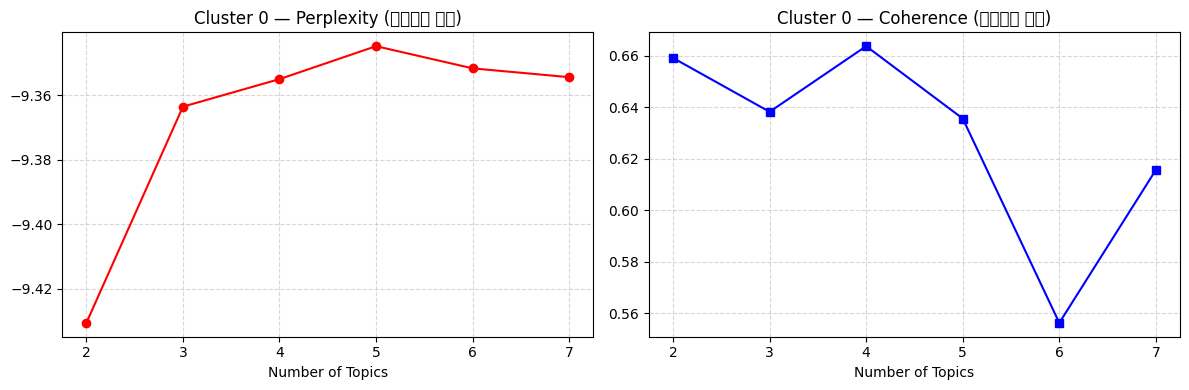


===== Cluster 1 탐색 시작 =====


Cluster 1:   0%|          | 0/6 [00:00<?, ?it/s]

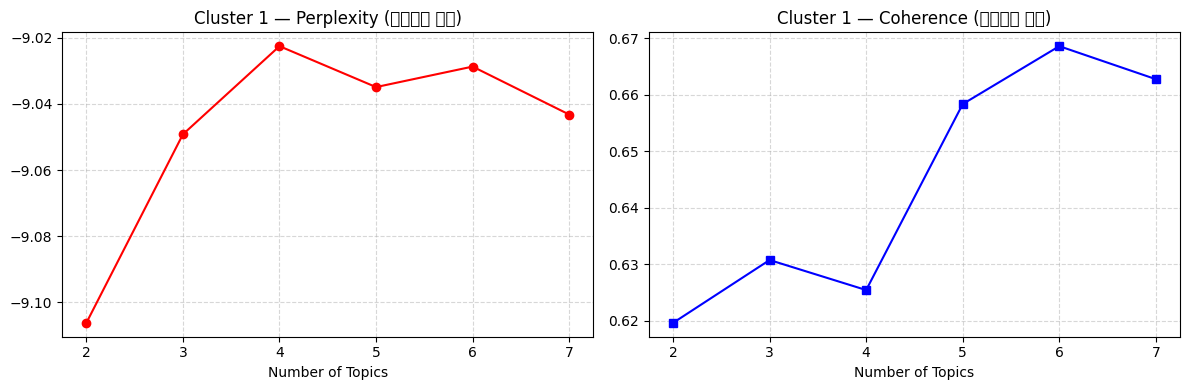


===== Cluster 2 탐색 시작 =====


Cluster 2:   0%|          | 0/6 [00:00<?, ?it/s]

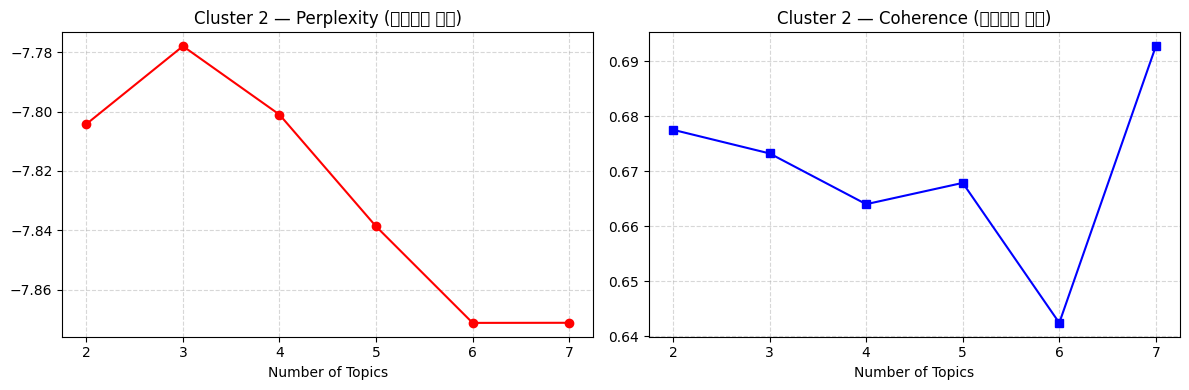


===== Cluster 3 탐색 시작 =====


Cluster 3:   0%|          | 0/6 [00:00<?, ?it/s]

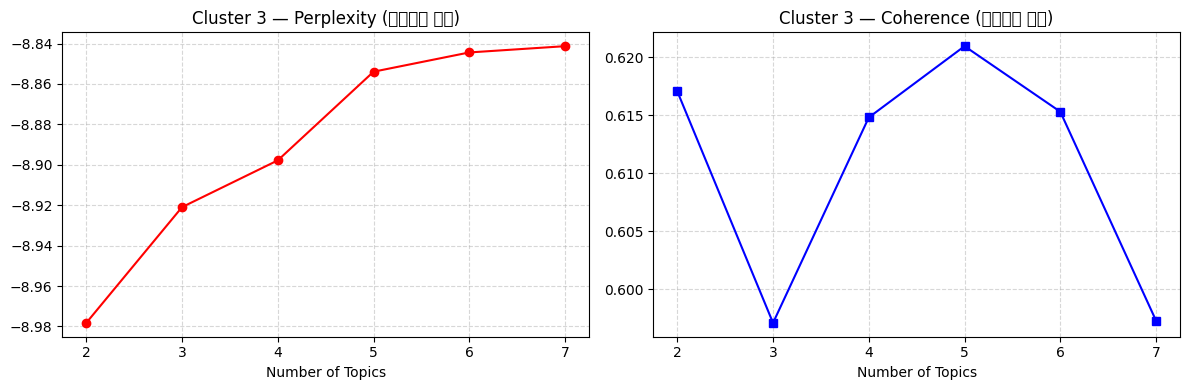


===== Cluster 4 탐색 시작 =====


Cluster 4:   0%|          | 0/6 [00:00<?, ?it/s]

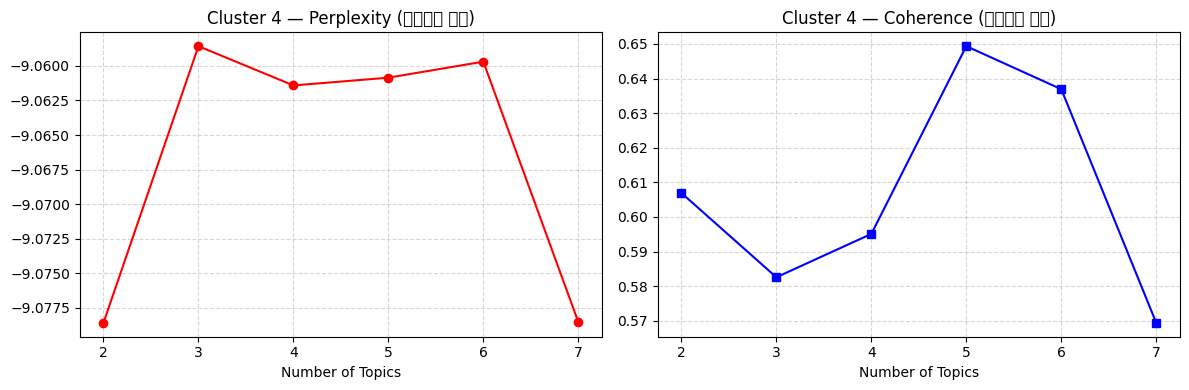


===== Cluster 5 탐색 시작 =====


Cluster 5:   0%|          | 0/6 [00:00<?, ?it/s]

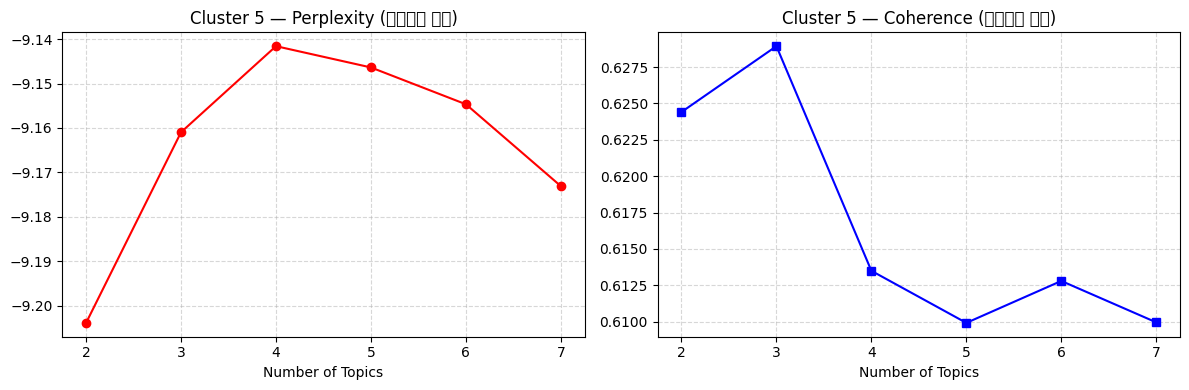


===== Cluster 6 탐색 시작 =====


Cluster 6:   0%|          | 0/6 [00:00<?, ?it/s]

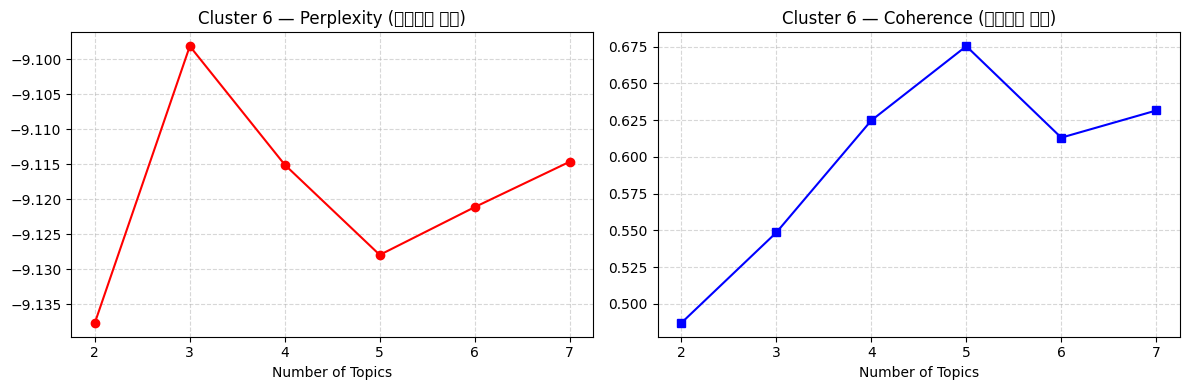


✅ 모든 클러스터 토픽 수 탐색 완료
→ 그래프 보고 topic_map을 아래 셀에서 지정하세요


In [ ]:
import gensim
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
import warnings
warnings.filterwarnings('ignore')

# ↓ 최종 결정한 K로 수정
FINAL_K = 7

# ── 클러스터별 최적 토픽 수 탐색 ──────────────────────────
cluster_list = sorted(df[f'cluster_K{FINAL_K}'].dropna().unique())
lda_search_results = {}

for cluster_num in cluster_list:
    print(f"\n===== Cluster {cluster_num} 탐색 시작 =====")

    df_cluster = df[df[f'cluster_K{FINAL_K}'] == cluster_num].copy()

    # text_ko를 띄어쓰기로 토크나이징
    all_documents = [
        str(text).split()
        for text in df_cluster['text']
        if isinstance(text, str) and len(str(text).strip()) > 0
    ]
    all_documents = [doc for doc in all_documents if len(doc) >= 3]

    if len(all_documents) < 5:
        print(f"Cluster {cluster_num}: 문서 수 부족으로 스킵")
        continue

    dictionary = Dictionary(all_documents)
    dictionary.filter_extremes(no_below=3, no_above=0.8)
    corpus = [dictionary.doc2bow(doc) for doc in all_documents]

    p_scores, c_scores = [], []
    topic_range = range(2, 8)

    for i in tqdm(topic_range, desc=f'Cluster {cluster_num}'):
        lda = gensim.models.ldamodel.LdaModel(
            corpus=corpus, num_topics=i, id2word=dictionary,
            random_state=42, passes=5
        )
        p_scores.append(lda.log_perplexity(corpus))
        cm = CoherenceModel(model=lda, texts=all_documents, dictionary=dictionary, topn=3)
        c_scores.append(cm.get_coherence())

    lda_search_results[cluster_num] = {
        'perplexity': p_scores,
        'coherence': c_scores,
        'topic_range': list(topic_range)
    }

    # 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(topic_range, p_scores, 'o-', color='red')
    ax1.set_title(f'Cluster {cluster_num} — Perplexity (낮을수록 좋음)')
    ax1.set_xlabel('Number of Topics')
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2.plot(topic_range, c_scores, 's-', color='blue')
    ax2.set_title(f'Cluster {cluster_num} — Coherence (높을수록 좋음)')
    ax2.set_xlabel('Number of Topics')
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(f'lda_search_cluster{cluster_num}.png', dpi=120)
    plt.show()

print("\n✅ 모든 클러스터 토픽 수 탐색 완료")
print("→ 그래프 보고 topic_map을 아래 셀에서 지정하세요")

In [ ]:
# ── 최종 LDA 실행 ──────────────────────────────────────────
# 위 그래프 보고 클러스터별 토픽 수 직접 지정
# 예시이므로 실행 후 반드시 수정
topic_map = {
    0: 4,
    1: 6,
    2: 7,
    3: 5,
    4: 5,
    5: 3,
    6: 5,
}  # ← 탐색 결과 보고 수정

cluster_results = {}
df_topic_list = []

for cluster_num, num_topics in topic_map.items():
    print(f"\n===== Cluster {cluster_num} | num_topics={num_topics} =====")

    df_cluster = df[df[f'cluster_K{FINAL_K}'] == cluster_num].copy()

    all_documents = [
        str(text).split()
        for text in df_cluster['text']
        if isinstance(text, str) and len(str(text).strip()) > 0
    ]
    all_documents = [doc for doc in all_documents if len(doc) >= 3]

    if not all_documents:
        print(f"Cluster {cluster_num}: 유효 데이터 부족, 스킵")
        continue

    dictionary = Dictionary(all_documents)
    dictionary.filter_extremes(no_below=3, no_above=0.8)
    corpus = [dictionary.doc2bow(doc) for doc in all_documents]

    lda = gensim.models.ldamodel.LdaModel(
        corpus=corpus, num_topics=num_topics, id2word=dictionary,
        random_state=42, passes=5, iterations=50, eval_every=None
    )

    # 문서별 대표 토픽 할당
    align = [
        sorted(lda.get_document_topics(doc), key=lambda x: x[1], reverse=True)[0][0]
        if lda.get_document_topics(doc) else 0
        for doc in corpus
    ]

    # 인덱스 맞춰서 topic 컬럼 추가
    valid_idx = df_cluster[[
        isinstance(text, str) and len(str(text).strip()) > 0
        for text in df_cluster['text']
    ]].index
    valid_idx = [i for i in valid_idx if len(str(df.loc[i, 'text']).split()) >= 3]

    for idx, topic in zip(valid_idx[:len(align)], align):
        df.loc[idx, 'topic'] = topic

    cluster_results[cluster_num] = {
        'ldamodel': lda,
        'corpus': corpus,
        'dictionary': dictionary
    }

    print(f"  토픽 분포: {dict(pd.Series(align).value_counts().sort_index())}")

# ── 저장 05 업데이트 ───────────────────────────────────────
df.to_pickle('05_df_with_clusters.pkl')
print("\n✅ 05_df_with_clusters.pkl 업데이트 (topic 컬럼 추가)")


===== Cluster 0 | num_topics=4 =====
  토픽 분포: {0: np.int64(996), 1: np.int64(780), 2: np.int64(1214), 3: np.int64(2033)}

===== Cluster 1 | num_topics=6 =====


  토픽 분포: {0: np.int64(211), 1: np.int64(838), 2: np.int64(777), 3: np.int64(345), 4: np.int64(1360), 5: np.int64(123)}

===== Cluster 2 | num_topics=7 =====


  토픽 분포: {0: np.int64(336), 1: np.int64(224), 2: np.int64(51), 3: np.int64(954), 4: np.int64(607), 5: np.int64(83), 6: np.int64(1547)}

===== Cluster 3 | num_topics=5 =====
  토픽 분포: {0: np.int64(701), 1: np.int64(1278), 2: np.int64(964), 3: np.int64(1865), 4: np.int64(990)}

===== Cluster 4 | num_topics=5 =====


  토픽 분포: {0: np.int64(682), 1: np.int64(731), 2: np.int64(183), 3: np.int64(169), 4: np.int64(362)}

===== Cluster 5 | num_topics=3 =====
  토픽 분포: {0: np.int64(631), 1: np.int64(3672), 2: np.int64(1577)}

===== Cluster 6 | num_topics=5 =====
  토픽 분포: {0: np.int64(2161), 1: np.int64(538), 2: np.int64(189), 3: np.int64(874), 4: np.int64(721)}

✅ 05_df_with_clusters.pkl 업데이트 (topic 컬럼 추가)


### sklearn LDA

클러스터별 최적 토픽 수 탐색 중...



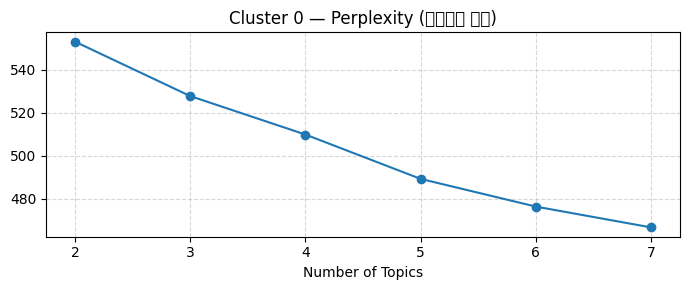

KeyboardInterrupt: 

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FINAL_K = 7  # ← 확정한 K

cluster_ids = sorted(df[f'cluster_K{FINAL_K}'].unique())

# ── STEP 1. 최적 토픽 수 탐색 ─────────────────────────────
print("클러스터별 최적 토픽 수 탐색 중...\n")

lda_search_results = {}

for cluster_num in cluster_ids:
    df_cluster = df[df[f'cluster_K{FINAL_K}'] == cluster_num]

    # tokens 컬럼 → 띄어쓰기 문자열로 변환
    docs = [' '.join(tokens) for tokens in df_cluster['tokens'] if len(tokens) > 0]

    if len(docs) < 5:
        print(f"Cluster {cluster_num}: 문서 수 부족 스킵")
        continue

    # CountVectorizer (LDA 입력용)
    cv = CountVectorizer(max_features=1000, min_df=2)
    dtm = cv.fit_transform(docs)

    perplexities = []
    topic_range = range(2, 8)

    for n in topic_range:
        lda = LatentDirichletAllocation(
            n_components=n,
            random_state=42,
            max_iter=20
        )
        lda.fit(dtm)
        perplexities.append(lda.perplexity(dtm))

    lda_search_results[cluster_num] = {
        'perplexity': perplexities,
        'topic_range': list(topic_range),
        'cv': cv,
        'dtm': dtm,
        'docs': docs
    }

    # 시각화
    plt.figure(figsize=(7, 3))
    plt.plot(topic_range, perplexities, 'o-', color='tab:blue')
    plt.title(f'Cluster {cluster_num} — Perplexity (낮을수록 좋음)')
    plt.xlabel('Number of Topics')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'lda_perplexity_cluster{cluster_num}.png', dpi=120)
    plt.show()

print("\n탐색 완료 → 그래프 보고 아래 topic_map 수정 후 실행")

---
## 재실행 가이드

| 재시작 지점 | 불러올 파일 |
|------------|------------|
| STEP 3 (PCA) 부터 | `03_df_with_embeddings.pkl` |
| STEP 4 (K 탐색) 부터 | `04_pca_result.npy` + `03_df_with_embeddings.pkl` |
| STEP 5 (클러스터링) 부터 | `04_pca_result.npy` + `03_df_with_embeddings.pkl` |
| STEP 6~7 (해석) 부터 | `05_df_with_clusters.pkl` |

각 STEP 셀 첫 줄에 주석 처리된 `pd.read_pickle` / `np.load` 코드를 해제해서 사용

In [ ]:
import pandas as pd
df = pd.read_pickle('05_df_with_clusters.pkl')
print("DataFrame loaded from '05_df_with_clusters.pkl'")
df.head()

DataFrame loaded from '05_df_with_clusters.pkl'


,text,embedding,cluster_K4,cluster_K7,cluster_K9,cluster_K11,tokens,topic
0,이번 제주여행 목표는\n🌼유채꽃구경 🌼\n🚘해안선드라이브 🚘\n☕️1일1카페가기☕️...,"[0.010075293, 0.04680805, -0.0068997312, 0.004...",1,0,7,3,"[이번, 제주, 여행, 목표, 유채, 구경, 해안선, 드라이브, 카페, 맛있, 시간...",3.0
1,살기 힘들다고 맨날 곡소리 내는 저...\n실상을 들여다보면 평일에 놀러다녀요 ㅋㅋ...,"[0.0075470684, 0.10550202, -0.009289928, -1.39...",3,6,8,6,"[힘들, 곡소리, 실상, 들여다보, 평일, 다니, 처자, 팔자, 평일, 다니, 휴직...",0.0
2,작년 2020년 코로나 상황으로 인해\n취소되었던 전국장애인체육대회가\n이번 년도에...,"[-0.01884854, 0.02153352, -0.004954029, 0.0564...",2,5,2,0,"[작년, 코로나, 상황, 인하, 취소, 전국, 장애인, 체육, 대회, 이번, 년도,...",0.0
3,엄마와 함께 경남 고성의\n라파엘 글램핑장에 다녀왔어요.\n엄마는 휠체어를 이용하셔...,"[0.034937114, 0.06827759, -0.007825643, -0.018...",2,0,7,3,"[엄마, 경남, 고성, 라파엘, 글램핑장, 다녀오, 엄마, 휠체어, 이용, 숙소, ...",0.0
4,#대학교체육관청소\n#체육관마루청소\n#휠체어타이어자국제거\n#깨끗한나라\n청소중\...,"[0.015588613, 0.09211508, -0.008896699, -0.004...",3,6,8,4,"[대학교, 체육관, 청소, 체육관, 마루, 청소, 휠체어, 타이어, 자국, 제거, ...",1.0


In [ ]:
df_cluster = df[df['cluster_K7'] == 0]
# df_cluster = df_cluster.dropna(subset=['topic'])
df_cluster.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5029 entries, 0 to 30914
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   text         5029 non-null   object 
 1   embedding    5029 non-null   object 
 2   cluster_K4   5029 non-null   int32  
 3   cluster_K7   5029 non-null   int32  
 4   cluster_K9   5029 non-null   int32  
 5   cluster_K11  5029 non-null   int32  
 6   tokens       5029 non-null   object 
 7   topic        5023 non-null   float64
dtypes: float64(1), int32(4), object(3)
memory usage: 275.0+ KB


In [ ]:

import gensim
from gensim import corpora, models
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

# 타겟 클러스터
all_documents = list(df_cluster['tokens'])
dictionary = Dictionary(all_documents)
# dictionary.token2id

corpus = [dictionary.doc2bow(i) for i in all_documents]

In [ ]:
ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = 4, id2word=dictionary, random_state=42)
#ldamodel.get_document_topics(corpus)[1]

align =[]
for i in ldamodel.get_document_topics(corpus):
  label = []
  value = []
  for t,v in i:
    label.append(t)
    value.append(v)
  align.append(label[np.argmax(value)])

df_cluster['topic'] = align
df_cluster

,text,embedding,cluster_K4,cluster_K7,cluster_K9,cluster_K11,tokens,topic
0,이번 제주여행 목표는\n🌼유채꽃구경 🌼\n🚘해안선드라이브 🚘\n☕️1일1카페가기☕️...,"[0.010075293, 0.04680805, -0.0068997312, 0.004...",1,0,7,3,"[이번, 제주, 여행, 목표, 유채, 구경, 해안선, 드라이브, 카페, 맛있, 시간...",3
3,엄마와 함께 경남 고성의\n라파엘 글램핑장에 다녀왔어요.\n엄마는 휠체어를 이용하셔...,"[0.034937114, 0.06827759, -0.007825643, -0.018...",2,0,7,3,"[엄마, 경남, 고성, 라파엘, 글램핑장, 다녀오, 엄마, 휠체어, 이용, 숙소, ...",3
5,2024.02\n이번 여행은 오래전부터 저와 함께했던\n여행 파트너인 승현이 하고 ...,"[0.026710562, 0.07738842, -0.0045695226, 0.008...",1,0,7,3,"[이번, 여행, 여행, 파트너, 승현, 여행, 승현, 초등학교, 물리, 치료사, 치...",3
8,휠체어여행 두바이 사막투어 4륜바이크 듄베이싱 1편\n2월 13일 드디어 내가 하고...,"[0.025638752, 0.038809057, -0.0054609166, -0.0...",1,0,7,3,"[휠체어, 여행, 두바이, 사막, 투어, 바이크, 듄베이싱, 오늘, 휠체어, 여행,...",3
10,안녕하세요 :)\n오늘은 대구 주민참여예산 사업으로 선정되어 진행된 사업 중 하나인...,"[0.0046706675, 0.06748217, -0.00660526, 0.0194...",1,0,7,3,"[안녕, 오늘, 대구, 주민, 참여, 예산, 사업, 선정, 진행, 사업, 도시철도,...",0
...,...,...,...,...,...,...,...,...
29920,94세 할머니 모시고 꽃놀이 다녀왔어요^^\n거동이 힘드셔서 모시고가기 어려웠는데 ...,"[-0.020807339, 0.06952744, -0.00886987, 0.0210...",1,0,7,2,"[할머니, 모시, 꽃놀이, 다녀오, 거동, 힘들, 모시, 어렵, 덕분, 편하, 다녀오]",3
30227,가성비는 좋지만 울퉁불퉁 지면에서는 승차감이 않좋다고 합니다,"[0.008797005, 0.06990123, -0.008404722, 0.0371...",0,0,5,3,"[가성비, 지면, 승차감]",3
30512,아스팔트 평평한 길은 무난하게 굴러가지만 조금 안좋은 길은 힘드네요\n옥외용으로 쓸...,"[0.022413334, 0.045061972, -0.007838654, 0.037...",0,0,7,3,"[아스팔트, 굴러가, 힘들, 옥외, 생각]",3
30748,할아버지와 공원산책 다녀왔는데 무겁지 않고 좋았습니다^^,"[-0.02609347, 0.07208309, -0.0074075256, 0.014...",1,0,7,3,"[할아버지, 공원, 산책, 다녀오, 무겁]",1


In [ ]:
import re

# Identify columns to drop using a regular expression pattern
columns_to_drop = [col for col in df.columns if re.match(r'cluster_K\d+', col)]

# Drop the identified columns
df = df.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
print(f"New DataFrame columns: {df.columns.tolist()}")

# Save the modified DataFrame to a new pickle file
df.to_pickle('clusters_no_0.pkl')
print("✅ 05_df_with_clusters_no_K_clusters.pkl saved successfully with cluster_Kx columns removed")

Dropped columns: ['cluster_K4', 'cluster_K7', 'cluster_K9', 'cluster_K11']
New DataFrame columns: ['text', 'embedding', 'tokens', 'topic']
✅ 05_df_with_clusters_no_K_clusters.pkl saved successfully with cluster_Kx columns removed


In [ ]:
# !pip install pyLDAvis

#visualize lda cluster
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

prepared_data = gensimvis.prepare(ldamodel, corpus, dictionary)
pyLDAvis.save_html(prepared_data, "ldavis_action_6.html")
pyLDAvis.display(prepared_data)

#pyLDAvis의 인덱스와 토픽인덱스가 같지 않다! 큰 순서로 매칭해야됨!!!
df_cluster['topic'].value_counts()

ModuleNotFoundError: No module named 'pyLDAvis'

In [ ]:

#불필요한 경고 지우기
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df.head()

,text,embedding,cluster_K4,cluster_K7,cluster_K9,cluster_K11,tokens,topic
0,이번 제주여행 목표는\n🌼유채꽃구경 🌼\n🚘해안선드라이브 🚘\n☕️1일1카페가기☕️...,"[0.010075293, 0.04680805, -0.0068997312, 0.004...",1,0,7,3,"[이번, 제주, 여행, 목표, 유채, 구경, 해안선, 드라이브, 카페, 맛있, 시간...",3.0
1,살기 힘들다고 맨날 곡소리 내는 저...\n실상을 들여다보면 평일에 놀러다녀요 ㅋㅋ...,"[0.0075470684, 0.10550202, -0.009289928, -1.39...",3,6,8,6,"[힘들, 곡소리, 실상, 들여다보, 평일, 다니, 처자, 팔자, 평일, 다니, 휴직...",0.0
2,작년 2020년 코로나 상황으로 인해\n취소되었던 전국장애인체육대회가\n이번 년도에...,"[-0.01884854, 0.02153352, -0.004954029, 0.0564...",2,5,2,0,"[작년, 코로나, 상황, 인하, 취소, 전국, 장애인, 체육, 대회, 이번, 년도,...",0.0
3,엄마와 함께 경남 고성의\n라파엘 글램핑장에 다녀왔어요.\n엄마는 휠체어를 이용하셔...,"[0.034937114, 0.06827759, -0.007825643, -0.018...",2,0,7,3,"[엄마, 경남, 고성, 라파엘, 글램핑장, 다녀오, 엄마, 휠체어, 이용, 숙소, ...",0.0
4,#대학교체육관청소\n#체육관마루청소\n#휠체어타이어자국제거\n#깨끗한나라\n청소중\...,"[0.015588613, 0.09211508, -0.008896699, -0.004...",3,6,8,4,"[대학교, 체육관, 청소, 체육관, 마루, 청소, 휠체어, 타이어, 자국, 제거, ...",1.0


In [ ]:
import pandas as pd
import gensim
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import os

In [ ]:

#min_max_scaling
def min_max(dic):
  result_dic = {}
  value = list(dic.values())
  minn = np.min(value)
  maxx = np.max(value)

  for k,v in dic.items():
    result_dic[k] = float((v-minn)/(maxx-minn))
  return result_dic

#필요한 클러스터의 df, model, corpus 리턴
def get_cluster_w_topic(cluster,num):
  df_cluster = df.loc[df['cluster_K7'] == cluster]
  all_documents = list(df_cluster['tokens'])
  dictionary = Dictionary(all_documents)
  corpus = [dictionary.doc2bow(i) for i in all_documents]

  ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = num, id2word=dictionary, random_state=42)
  align =[]
  for i in ldamodel.get_document_topics(corpus):
    label = []
    value = []
    for t,v in i:
      label.append(t)
      value.append(v)
    align.append(label[np.argmax(value)])

  df_cluster['topic'] = align

  return (df_cluster, corpus, ldamodel)

import json
with open('SentiWord_info.json', encoding= "utf-8-sig", mode = 'r') as f:
  sent_dicts = json.load(f)
sd = {i['word']:int(i['polarity']) for i in sent_dicts}

def sentiment_score(sent_dicts, token_list):
  result = [sd[i] for i in token_list if i in sd]
  return 0 if len(result) == 0 else np.mean(result)

def get_sents(df):
  df['sentiment'] = df['tokens'].apply(lambda x: sentiment_score(sd,x))

  action_sents = {}
  for i in df['topic'].unique():
    action_sents[int(i)] = float(np.mean(df.loc[df['topic'] == i]['sentiment']))

  normalized_action_sents = min_max(action_sents)
  print('sentiment', normalized_action_sents)
  return normalized_action_sents

def get_imps(ldamodel, corpus,num):
  prob = []
  for i in ldamodel.get_document_topics(corpus):
    temp = {i:0 for i in range(num)}
    for k,v in i:
      temp[k] = float(v)
    prob.append(list(temp.values()))

  value = np.array(prob).mean(axis=0)
  action_imp = {}
  for i in range(len(prob[0])):
    action_imp[i] = float(value[i])

  normalized_action_imp = min_max(action_imp)
  print('importance',normalized_action_imp)
  return normalized_action_imp


def get_opp(normalized_action_sents,normalized_action_imp,num):
  opportunity_score = {}
  for i in range(num):
    sat = normalized_action_sents[i]
    imp = normalized_action_imp[i]

    opportunity_score[i] = imp + float(np.max([imp-sat,0]))

  print('opportunity',opportunity_score)
  return opportunity_score


## ============== 중요도, 만족도, 기회 점수 구하기 =================

# df에 클러스터 피클 파일 불러오기
df = pd.read_pickle('05_df_with_clusters.pkl')


all_res = []
# 각 클러스터의 토픽 개수 넣어주세요
nums = [4,6,7,5,5,3,5]
for i in df['cluster_K7'].unique():
  df_cluster, corpus, ldamodel = get_cluster_w_topic(i,nums[i])
  sent = get_sents(df_cluster)
  imp = get_imps(ldamodel,corpus,nums[i])
  opp = get_opp(sent, imp,nums[i])
  all_res.append((int(i),sent,imp,opp))

print(all_res)

## ==============


sents_df = pd.DataFrame(columns = ['action','satisfaction', 'importance','opportunity'])
for cluster in all_res:
  idx = cluster[0]
  sents = cluster[1]
  imp = cluster[2]
  opp = cluster[3]
  for i in range(len(sents)):
    sents_df.loc[len(sents_df)] = [f'cluster{idx}action{i}',sents[i],imp[i],opp[i]]

print(sents_df)


sentiment {3: 0.0, 0: 1.0, 2: 0.5911465282437441, 1: 0.8799777616677857}
importance {0: 0.0, 1: 0.3775840823517303, 2: 0.1806356255252523, 3: 1.0}
opportunity {0: 0.0, 1: 0.3775840823517303, 2: 0.1806356255252523, 3: 2.0}


sentiment {3: 0.0, 0: 0.9728313521054532, 2: 0.31268389167932914, 4: 1.0, 1: 0.5168564058257956}
importance {0: 1.0, 1: 0.271432823922013, 2: 0.4001292168010059, 3: 0.0, 4: 0.1604352413608625}
opportunity {0: 1.0271686478945468, 1: 0.271432823922013, 2: 0.4875745419226826, 3: 0.0, 4: 0.1604352413608625}


sentiment {0: 0.0, 1: 0.6295150617322418, 2: 1.0}
importance {0: 1.0, 1: 0.017649467823263786, 2: 0.0}
opportunity {0: 2.0, 1: 0.017649467823263786, 2: 0.0}


sentiment {3: 1.0, 2: 0.0012961289406844, 0: 0.0, 4: 0.7464169468792158, 1: 0.3334074335066413}
importance {0: 0.2883160101002245, 1: 0.0, 2: 0.18843481702631718, 3: 1.0, 4: 0.06105486264110919}
opportunity {0: 0.576632020200449, 1: 0.0, 2: 0.37557350511195, 3: 1.0, 4: 0.06105486264110919}


sentiment {4: 1.0, 5: 0.4463132008499373, 1: 0.32879018863557835, 0: 0.19470587540684398, 3: 0.0869940466584534, 2: 0.0}


importance {0: 1.0, 1: 0.46515298638505426, 2: 0.6699902969624673, 3: 0.2605393447128227, 4: 0.8834247681283701, 5: 0.0}
opportunity {0: 1.805294124593156, 1: 0.6015157841345302, 2: 1.3399805939249345, 3: 0.434084642767192, 4: 0.8834247681283701, 5: 0.0}
sentiment {1: 0.5345929635449255, 0: 1.0, 4: 0.5954721259494181, 2: 0.5350914662986505, 6: 0.47809292512886864, 3: 0.7065600917967398, 5: 0.0}
importance {0: 0.755147495624397, 1: 0.5835034708882556, 2: 0.17616433998671968, 3: 0.06522351995922193, 4: 0.0, 5: 0.31140374866010717, 6: 1.0}
opportunity {0: 0.755147495624397, 1: 0.6324139782315857, 2: 0.17616433998671968, 3: 0.06522351995922193, 4: 0.0, 5: 0.6228074973202143, 6: 1.5219070748711314}


sentiment {4: 1.0, 3: 0.21713323518657138, 1: 0.2714531317469814, 2: 0.0, 0: 0.155354559138631}
importance {0: 1.0, 1: 0.38912264740589086, 2: 0.10147837716979821, 3: 0.5092174263227313, 4: 0.0}
opportunity {0: 1.844645440861369, 1: 0.5067921630648003, 2: 0.20295675433959642, 3: 0.8013016174588912, 4: 0.0}
[(0, {3: 0.0, 0: 1.0, 2: 0.5911465282437441, 1: 0.8799777616677857}, {0: 0.0, 1: 0.3775840823517303, 2: 0.1806356255252523, 3: 1.0}, {0: 0.0, 1: 0.3775840823517303, 2: 0.1806356255252523, 3: 2.0}), (6, {3: 0.0, 0: 0.9728313521054532, 2: 0.31268389167932914, 4: 1.0, 1: 0.5168564058257956}, {0: 1.0, 1: 0.271432823922013, 2: 0.4001292168010059, 3: 0.0, 4: 0.1604352413608625}, {0: 1.0271686478945468, 1: 0.271432823922013, 2: 0.4875745419226826, 3: 0.0, 4: 0.1604352413608625}), (5, {0: 0.0, 1: 0.6295150617322418, 2: 1.0}, {0: 1.0, 1: 0.017649467823263786, 2: 0.0}, {0: 2.0, 1: 0.017649467823263786, 2: 0.0}), (3, {3: 1.0, 2: 0.0012961289406844, 0: 0.0, 4: 0.7464169468792158, 1: 0.3334074335

In [ ]:
all_res

In [ ]:

#min_max_scaling
def min_max(dic):
  result_dic = {}
  value = list(dic.values())
  minn = np.min(value)
  maxx = np.max(value)

  for k,v in dic.items():
    # Handle cases where max and min are the same to avoid division by zero
    if (maxx - minn) == 0:
      result_dic[k] = 0.0 # Or 0.5, or a suitable default if all values are identical
    else:
      result_dic[k] = float((v-minn)/(maxx-minn))
  return result_dic

#필요한 클러스터의 df, model, corpus 리턴
def get_cluster_w_topic(cluster,num):
  df_cluster = df.loc[df['cluster_K7'] == cluster]
  all_documents = list(df_cluster['tokens'])
  dictionary = Dictionary(all_documents)
  corpus = [dictionary.doc2bow(i) for i in all_documents]

  ldamodel = gensim.models.ldamodel.LdaModel(corpus, num_topics = num, id2word=dictionary, random_state=42)
  align =[]
  for i in ldamodel.get_document_topics(corpus):
    label = []
    value = []
    for t,v in i:
      label.append(t)
      value.append(v)
    align.append(label[np.argmax(value)])

  df_cluster['topic'] = align

  return (df_cluster, corpus, ldamodel)

import json
with open('SentiWord_info.json', encoding= "utf-8-sig", mode = 'r') as f:
  sent_dicts = json.load(f)
sd = {i['word']:int(i['polarity']) for i in sent_dicts}

def sentiment_score(sent_dicts, token_list):
  result = [sd[i] for i in token_list if i in sd]
  return 0 if len(result) == 0 else np.mean(result)

def get_sents(df):
  df['sentiment'] = df['tokens'].apply(lambda x: sentiment_score(sd,x))

  action_sents = {}
  for i in df['topic'].unique():
    action_sents[int(i)] = float(np.mean(df.loc[df['topic'] == i]['sentiment']))

  normalized_action_sents = min_max(action_sents)
  print('sentiment', normalized_action_sents)
  return normalized_action_sents

def get_imps(ldamodel, corpus,num):
  prob = []
  for i in ldamodel.get_document_topics(corpus):
    temp = {i:0 for i in range(num)}
    for k,v in i:
      temp[k] = float(v)
    prob.append(list(temp.values()))

  value = np.array(prob).mean(axis=0)
  action_imp = {}
  for i in range(len(prob[0])):
    action_imp[i] = float(value[i])

  normalized_action_imp = min_max(action_imp)
  print('importance',normalized_action_imp)
  return normalized_action_imp


def get_opp(normalized_action_sents,normalized_action_imp,num):
  opportunity_score = {}
  for i in range(num):
    sat = normalized_action_sents[i]
    imp = normalized_action_imp[i]

    # Calculate raw opportunity score
    opportunity_score[i] = imp + float(np.max([imp-sat,0]))

  # Normalize the opportunity scores to be between 0 and 1
  normalized_opportunity_score = min_max(opportunity_score)

  # Changed this line to print the normalized score
  print('opportunity', normalized_opportunity_score)
  return normalized_opportunity_score


## ============== 중요도, 만족도, 기회 점수 구하기 =================

# df에 클러스터 피클 파일 불러오기
df = pd.read_pickle('05_df_with_clusters.pkl')


all_res = []
# 각 클러스터의 토픽 개수 넣어주세요
nums = [4,6,7,5,5,3,5]
for i in df['cluster_K7'].unique():
  df_cluster, corpus, ldamodel = get_cluster_w_topic(i,nums[i])
  sent = get_sents(df_cluster)
  imp = get_imps(ldamodel,corpus,nums[i])
  opp = get_opp(sent, imp,nums[i])
  all_res.append((int(i),sent,imp,opp))

print(all_res)

## ==============


sents_df = pd.DataFrame(columns = ['action','satisfaction', 'importance','opportunity'])
for cluster in all_res:
  idx = cluster[0]
  sents = cluster[1]
  imp = cluster[2]
  opp = cluster[3]
  for i in range(len(sents)):
    sents_df.loc[len(sents_df)] = [f'cluster{idx}action{i}',sents[i],imp[i],opp[i]]

print(sents_df)


sentiment {3: 0.0, 0: 1.0, 2: 0.5911465282437441, 1: 0.8799777616677857}
importance {0: 0.0, 1: 0.3775840823517303, 2: 0.1806356255252523, 3: 1.0}
opportunity {0: 0.0, 1: 0.18879204117586515, 2: 0.09031781276262615, 3: 1.0}


sentiment {3: 0.0, 0: 0.9728313521054532, 2: 0.31268389167932914, 4: 1.0, 1: 0.5168564058257956}
importance {0: 1.0, 1: 0.271432823922013, 2: 0.4001292168010059, 3: 0.0, 4: 0.1604352413608625}
opportunity {0: 1.0, 1: 0.2642534159102171, 2: 0.47467817765086123, 3: 0.0, 4: 0.15619172342313686}


sentiment {0: 0.0, 1: 0.6295150617322418, 2: 1.0}
importance {0: 1.0, 1: 0.017649467823263786, 2: 0.0}
opportunity {0: 1.0, 1: 0.008824733911631893, 2: 0.0}


sentiment {3: 1.0, 2: 0.0012961289406844, 0: 0.0, 4: 0.7464169468792158, 1: 0.3334074335066413}
importance {0: 0.2883160101002245, 1: 0.0, 2: 0.18843481702631718, 3: 1.0, 4: 0.06105486264110919}
opportunity {0: 0.576632020200449, 1: 0.0, 2: 0.37557350511195, 3: 1.0, 4: 0.06105486264110919}


sentiment {4: 1.0, 5: 0.4463132008499373, 1: 0.32879018863557835, 0: 0.19470587540684398, 3: 0.0869940466584534, 2: 0.0}


importance {0: 1.0, 1: 0.46515298638505426, 2: 0.6699902969624673, 3: 0.2605393447128227, 4: 0.8834247681283701, 5: 0.0}
opportunity {0: 1.0, 1: 0.3331954477335314, 2: 0.7422505705140511, 3: 0.24045092533883808, 4: 0.4893522645942584, 5: 0.0}
sentiment {1: 0.5345929635449255, 0: 1.0, 4: 0.5954721259494181, 2: 0.5350914662986505, 6: 0.47809292512886864, 3: 0.7065600917967398, 5: 0.0}
importance {0: 0.755147495624397, 1: 0.5835034708882556, 2: 0.17616433998671968, 3: 0.06522351995922193, 4: 0.0, 5: 0.31140374866010717, 6: 1.0}
opportunity {0: 0.4961850221297773, 1: 0.4155404680572471, 2: 0.11575236287119338, 3: 0.042856440472717285, 4: 0.0, 5: 0.4092283343731423, 6: 1.0}


sentiment {4: 1.0, 3: 0.21713323518657138, 1: 0.2714531317469814, 2: 0.0, 0: 0.155354559138631}
importance {0: 1.0, 1: 0.38912264740589086, 2: 0.10147837716979821, 3: 0.5092174263227313, 4: 0.0}
opportunity {0: 1.0, 1: 0.27473689622876823, 2: 0.11002480468269527, 3: 0.4343932984133353, 4: 0.0}
[(0, {3: 0.0, 0: 1.0, 2: 0.5911465282437441, 1: 0.8799777616677857}, {0: 0.0, 1: 0.3775840823517303, 2: 0.1806356255252523, 3: 1.0}, {0: 0.0, 1: 0.18879204117586515, 2: 0.09031781276262615, 3: 1.0}), (6, {3: 0.0, 0: 0.9728313521054532, 2: 0.31268389167932914, 4: 1.0, 1: 0.5168564058257956}, {0: 1.0, 1: 0.271432823922013, 2: 0.4001292168010059, 3: 0.0, 4: 0.1604352413608625}, {0: 1.0, 1: 0.2642534159102171, 2: 0.47467817765086123, 3: 0.0, 4: 0.15619172342313686}), (5, {0: 0.0, 1: 0.6295150617322418, 2: 1.0}, {0: 1.0, 1: 0.017649467823263786, 2: 0.0}, {0: 1.0, 1: 0.008824733911631893, 2: 0.0}), (3, {3: 1.0, 2: 0.0012961289406844, 0: 0.0, 4: 0.7464169468792158, 1: 0.3334074335066413}, {0: 0.28831601

In [ ]:
import matplotlib.pyplot as plt


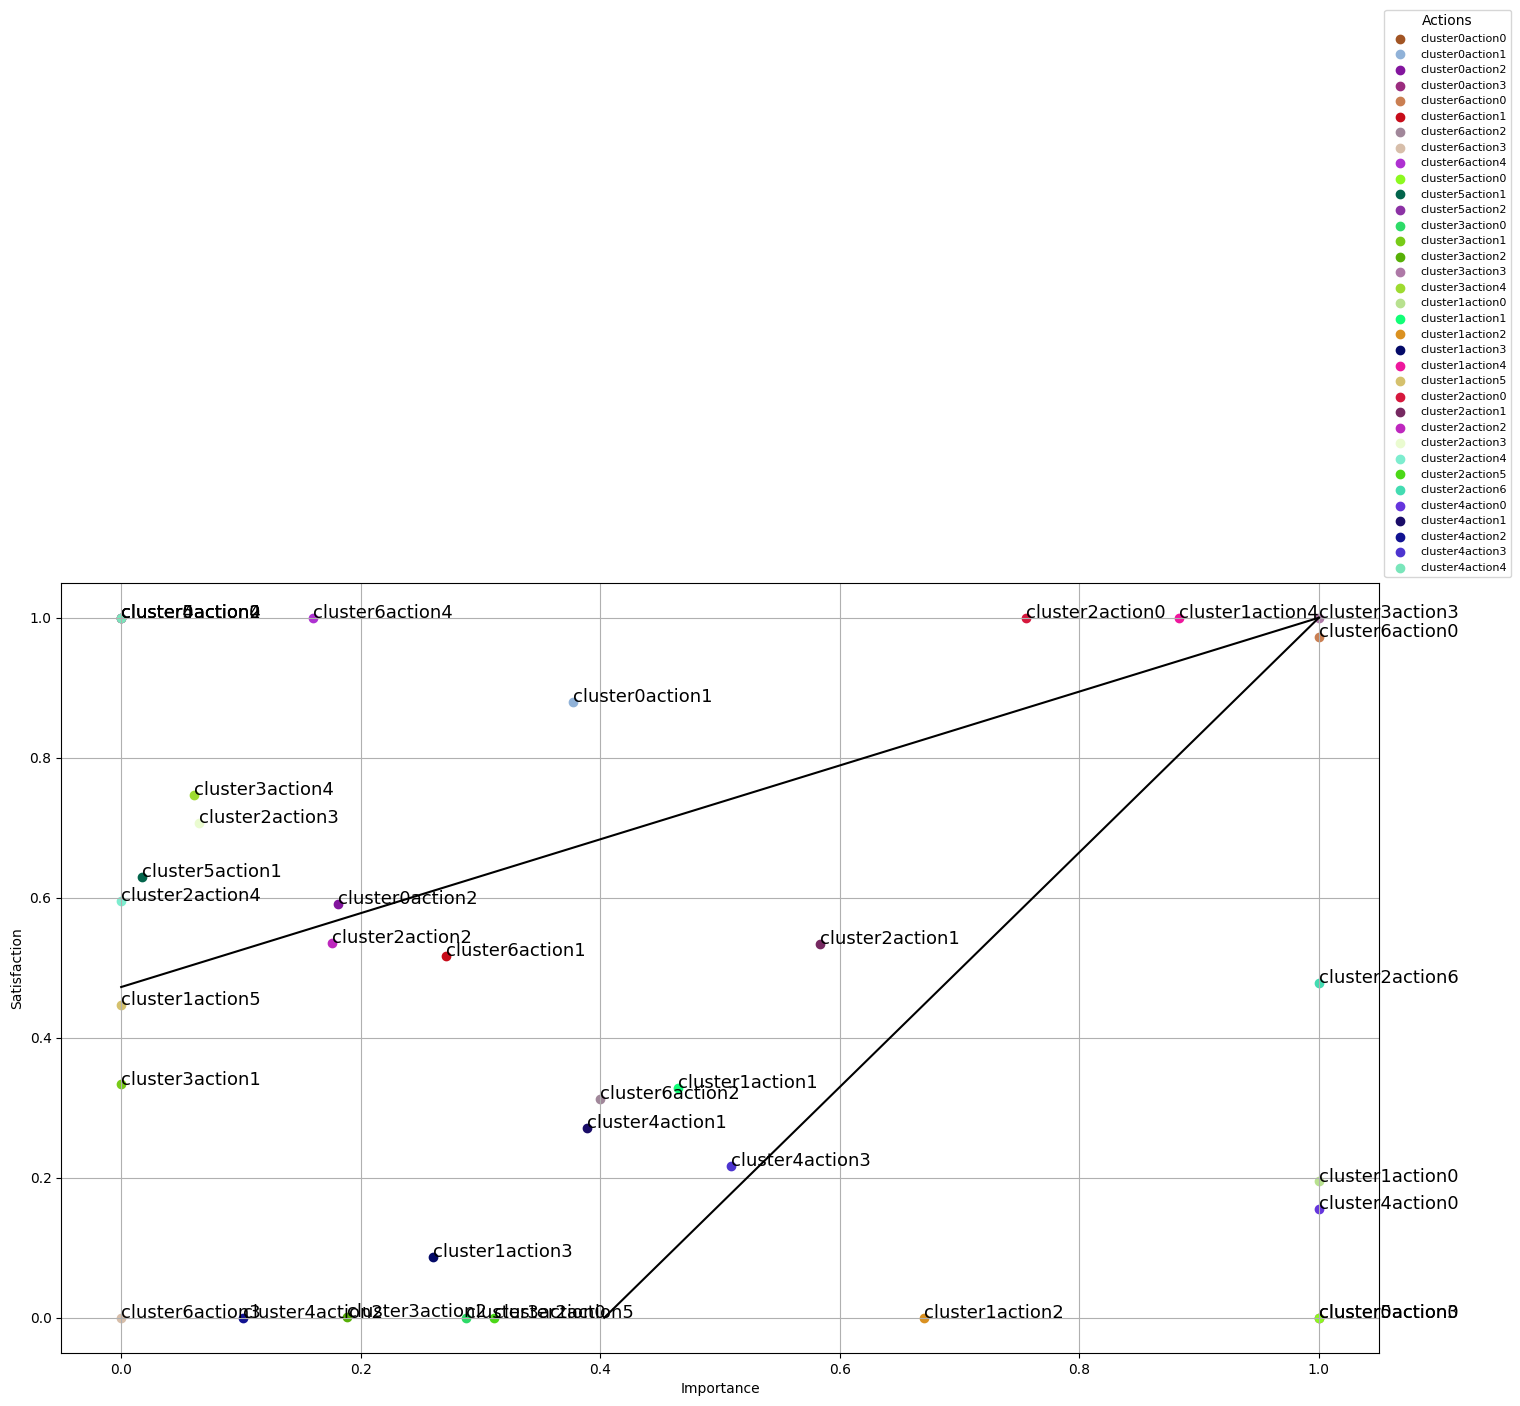

In [ ]:
import matplotlib.pyplot as plt

actions = sents_df['action']
colors = np.random.rand(len(actions),3) #rgb내에서 리스트 길이만큼 랜덤 색깔 선택
imp = sents_df['importance']
sat = sents_df['satisfaction']

plt.figure(figsize=(17,10))

for i, action in enumerate(actions):
  plt.scatter(imp[i],sat[i],c = [colors[i]],label= action)

plt.legend(title='Actions', fontsize = 8, title_fontsize = 10, loc='best',bbox_to_anchor = (1,1))
plt.xlabel('Importance')
plt.ylabel('Satisfaction')

#만족도 기준선
x_data = [0,1]
y_data = [sat.mean(),1]
plt.plot(x_data, y_data, 'k-')

#중요도 기준선
x_data = [imp.mean(),1]
y_data = [0,1]
plt.plot(x_data, y_data, 'k-')

#legend for each point
texts = []
for i, action in enumerate(actions):
  texts.append(plt.text(imp[i], sat[i], action, fontsize = 13))

plt.grid(True)
plt.savefig('Opportunity area.png', dpi=300, bbox_inches='tight')

In [ ]:
import pandas as pd

# Load the DataFrame from the pickle file
df_to_csv = pd.read_pickle('05_df_with_clusters.pkl') # Or '05_df_with_clusters.pkl' if you prefer that one

# Save the DataFrame to a CSV file
output_csv_filename = 'output_dataframe.csv'
df_to_csv.to_csv(output_csv_filename, index=False, encoding='utf-8')

print(f"DataFrame successfully converted and saved to '{output_csv_filename}'")

DataFrame successfully converted and saved to 'output_dataframe.csv'
